# Klasifikasi Vokalisasi Gelatik Jawa (*Lonchura oryzivora*) Menggunakan MFCC dan Mel-Spectrogram pada RF, CNN, dan LSTM

Notebook ini berisi seluruh pipeline implementasi tugas akhir, diorganisasikan mengikuti struktur Bab IV laporan. Setiap section berkorespondensi dengan satu sub-bab/sub-sub-bab pada laporan untuk memudahkan audit silang antara kode dan narasi laporan.

Tahapan:  
(a) *Dataset Development* — Data Collection, Data Preparation;  
(b) *Model Development* — Data Exploration, Feature Engineering, Model Configuration, Model Validation, Model Training;  
(c) *Model Evaluation*;   
(d) *Model Implementation*.

## Preparation

Mounting Google Drive, instalasi pustaka, *import library*, penetapan *seed reproducibility*, dan *setup path* direktori kerja.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tensorflow numba librosa pydub noisereduce tqdm

Mounted at /content/drive


In [3]:
import os
import json
import random
import time
import shutil
import re
from collections import Counter
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr
from pydub import AudioSegment
from tqdm.notebook import tqdm
import IPython.display as ipd

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import backend as K

import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [4]:
# ── Seed global untuk reproducibility ──────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [5]:
# ── Setup path direktori ───────────────────────────────────────────────────
parent_path = Path('/content/drive/MyDrive/UAJY/Gelatik Jawa')

prep_path = parent_path / "Preprocessed Audio"
stage_paths = {
    "wav":      prep_path / "01_wav16k",
    "denoise":  prep_path / "02_denoised",
    "normloud": prep_path / "03_normloud",
    "fixedlen": prep_path / "04_fixedlen",
}
for p in stage_paths.values():
    p.mkdir(parents=True, exist_ok=True)

dataset_path     = parent_path / "Dataset"
feature_root     = parent_path / "Features"
model_dir        = parent_path / "Models"
label_meta_dir   = parent_path / "Meta"
ckpt_dir         = feature_root / "checkpoints"
training_log_dir = feature_root / "training_logs"
for d in (model_dir, label_meta_dir, ckpt_dir, training_log_dir):
    d.mkdir(parents=True, exist_ok=True)

In [6]:
# ── Utilitas filesystem (digunakan lintas tahap) ──────────────────────────
def reset_dir(p: Path, force: bool = False) -> None:
    """Hapus isi direktori dan buat ulang. Memerlukan force=True secara eksplisit."""
    if p.exists() and any(p.iterdir()):
        if not force:
            raise RuntimeError(
                f"Direktori {p} sudah berisi data. "
                f"Gunakan reset_dir({p!r}, force=True) jika ingin menghapusnya."
            )
        shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)


def sanitize_filename(filename: str) -> str:
    """Bersihkan karakter non-alfanumerik dari nama berkas agar aman lintas-OS."""
    return re.sub(r'[^a-zA-Z0-9_\-]', '_', filename)

# Dataset Development

## Data Collection

Pengumpulan dataset audio dari hasil rekaman lapangan dan repositori Macaulay Library, terorganisasi dalam dua kelas: `Javan Sparrow` dan `Others`. Direktori dataset di-resolve relatif terhadap `parent_path`.

In [ ]:
class_folders = [
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
]

grand_total = 0
print(f"Folder: {dataset_path}")
for class_folder in class_folders:
    class_path = os.path.join(dataset_path, class_folder)
    ext_counter = Counter()
    class_total = 0
    for root, _, files in os.walk(class_path):
        for fn in files:
            ext = os.path.splitext(fn)[1].lower()
            ext_counter[ext] += 1
            class_total += 1
    grand_total += class_total
    print(f"\nKelas: {class_folder}")
    print(f"  Total file  : {class_total}")
    print("  Ekstensi    :")
    for ext, count in sorted(ext_counter.items()):
        print(f"    {ext or '[no extension]'}: {count}")
print(f"\nTotal file dataset: {grand_total}")

Folder: /content/drive/MyDrive/UAJY/Gelatik Jawa/Dataset

Kelas: Javan Sparrow
  Total file  : 418
  Ekstensi    :
    .m4a: 16
    .mp3: 5
    .wav: 397

Kelas: Others
  Total file  : 602
  Ekstensi    :
    .flac: 573
    .wav: 29

Total file dataset: 1020


## Data Preparation

Empat tahap *preprocessing* berurutan: (1) konversi format ke WAV mono 16 kHz, (2) reduksi derau berbasis profil 0,5 detik awal sinyal, (3) normalisasi volume RMS ke −20 dBFS, dan (4) normalisasi durasi 5 detik melalui *silence padding* atau pemotongan. Setiap tahap menyimpan keluaran ke direktori terpisah untuk mendukung audit intermediate dan idempotensi pemrosesan ulang.

In [13]:
# ── Fungsi preprocessing ──────────────────────────────────────────────────
def convert_to_wav(src_path: str, dst_path: str, target_sr: int = 16000) -> bool:
    """Konversi audio sumber ke WAV mono dengan sampling rate target."""
    try:
        audio = AudioSegment.from_file(src_path)
        audio = audio.set_frame_rate(target_sr).set_channels(1)
        audio.export(dst_path, format="wav")
        return True
    except Exception as e:
        print(f"Gagal konversi WAV {src_path}: {e}")
        return False


def reduce_noise(src_path: str, dst_path: str, profile_duration: float = 0.5) -> bool:
    """Reduksi noise berbasis profil dari `profile_duration` detik awal sinyal."""
    try:
        y, sr = librosa.load(src_path, sr=None)
        profile_samples = int(profile_duration * sr)
        noise_clip = y[:profile_samples]
        y_reduced = nr.reduce_noise(y=y, sr=sr, y_noise=noise_clip)
        sf.write(dst_path, y_reduced, sr)
        return True
    except Exception as e:
        print(f"Gagal noise reduction {src_path}: {e}")
        return False


def normalize_volume(
    src_path: str, dst_path: str, target_dBFS: float = -20.0,
) -> bool:
    """Normalisasi RMS sinyal ke target_dBFS, dengan clipping aman pada [-1, 1]."""
    try:
        y, sr = librosa.load(src_path, sr=None)
        rms = np.sqrt(np.mean(y ** 2))
        current_dBFS = 20 * np.log10(rms) if rms > 0 else -np.inf
        change_dBFS = target_dBFS - current_dBFS
        scaling_factor = 10 ** (change_dBFS / 20)
        y_normalized = np.clip(y * scaling_factor, -1.0, 1.0)
        sf.write(dst_path, y_normalized, sr)
        return True
    except Exception as e:
        print(f"Gagal normalisasi volume {src_path}: {e}")
        return False


def normalize_duration(
    src_path: str,
    dst_path: str,
    target_sr: int = 16000,
    target_duration: float = 5.0,
) -> bool:
    """Padding dengan silence atau trim ke `target_duration` detik."""
    try:
        audio = AudioSegment.from_file(src_path)
        audio = audio.set_frame_rate(target_sr).set_channels(1)
        target_ms = int(target_duration * 1000)
        if len(audio) < target_ms:
            silence = AudioSegment.silent(duration=target_ms - len(audio))
            audio = audio + silence
        else:
            audio = audio[:target_ms]
        audio.export(dst_path, format="wav")
        return True
    except Exception as e:
        print(f"Gagal normalisasi durasi {src_path}: {e}")
        return False

In [ ]:
# ── Reset direktori output preprocessing ──────────────────────────────────
for p in stage_paths.values():
    reset_dir(p, force=False)

In [ ]:
# ── Stage 1: Konversi ke WAV 16 kHz mono ──────────────────────────────────
AUDIO_EXTS = ('.wav', '.flac', '.mp3', '.ogg', '.m4a')

src_root = dataset_path
dst_root = stage_paths["wav"]

grand_total = sum(
    1 for root, _, files in os.walk(src_root)
    for f in files if f.lower().endswith(AUDIO_EXTS)
)
print(f"Total file audio ditemukan: {grand_total}")

count = 0
with tqdm(total=grand_total, desc="Stage 1 — Konversi WAV", unit="file") as pbar:
    for root, _, files in os.walk(src_root):
        rel = os.path.relpath(root, src_root)
        if rel == ".":
            continue
        cls = rel.split(os.sep)[0]
        target_dir = dst_root / cls
        target_dir.mkdir(parents=True, exist_ok=True)

        within_class = rel.split(os.sep, 1)[1] if os.sep in rel else ""
        within_class_safe = (
            sanitize_filename(within_class.replace(os.sep, "__"))
            if within_class else ""
        )
        for file_name in files:
            if not file_name.lower().endswith(AUDIO_EXTS):
                continue
            src_file = Path(root) / file_name
            base_stem = sanitize_filename(Path(file_name).stem)
            out_name = (
                f"{within_class_safe}__{base_stem}.wav"
                if within_class_safe else f"{base_stem}.wav"
            )
            dst_file = target_dir / out_name
            if convert_to_wav(str(src_file), str(dst_file), target_sr=16000):
                count += 1
            pbar.update(1)
            pbar.set_postfix(success=count)

print(f"Stage 1 selesai: {count} file -> {dst_root}")

Total file audio ditemukan: 1020


Stage 1 — Konversi WAV:   0%|          | 0/1020 [00:00<?, ?file/s]

Stage 1 selesai: 1020 file -> /content/drive/MyDrive/UAJY/Skripsi/Preprocessed Audio/01_wav16k


In [ ]:
# ── Stage 2: Noise reduction ──────────────────────────────────────────────
count = 0
src_root = stage_paths["wav"]
dst_root = stage_paths["denoise"]

with tqdm(total=grand_total, desc="Stage 2 — Noise Reduction", unit="file") as pbar:
    for root, _, files in os.walk(src_root):
        rel_path = os.path.relpath(root, src_root)
        target_dir = dst_root / rel_path
        target_dir.mkdir(parents=True, exist_ok=True)
        for file_name in files:
            if not file_name.lower().endswith('.wav'):
                continue
            src_file = Path(root) / file_name
            safe_stem = sanitize_filename(Path(file_name).stem)
            dst_file = target_dir / f"{safe_stem}.wav"
            if reduce_noise(str(src_file), str(dst_file)):
                count += 1
            pbar.update(1)
            pbar.set_postfix(success=count)

print(f"Stage 2 selesai: {count} file -> {dst_root}")

Stage 2 — Noise Reduction:   0%|          | 0/1020 [00:00<?, ?file/s]

Stage 2 selesai: 1020 file -> /content/drive/MyDrive/UAJY/Skripsi/Preprocessed Audio/02_denoised


In [ ]:
# ── Stage 3: Normalisasi volume (-20 dBFS RMS) ────────────────────────────
count = 0
src_root = stage_paths["denoise"]
dst_root = stage_paths["normloud"]

with tqdm(total=grand_total, desc="Stage 3 — Volume Normalization", unit="file") as pbar:
    for root, _, files in os.walk(src_root):
        rel_path = os.path.relpath(root, src_root)
        target_dir = dst_root / rel_path
        target_dir.mkdir(parents=True, exist_ok=True)
        for file_name in files:
            if not file_name.lower().endswith('.wav'):
                continue
            src_file = Path(root) / file_name
            safe_stem = sanitize_filename(Path(file_name).stem)
            dst_file = target_dir / f"{safe_stem}.wav"
            if normalize_volume(str(src_file), str(dst_file)):
                count += 1
            pbar.update(1)
            pbar.set_postfix(success=count)

print(f"Stage 3 selesai: {count} file -> {dst_root}")

Stage 3 — Volume Normalization:   0%|          | 0/1020 [00:00<?, ?file/s]

Stage 3 selesai: 1020 file -> /content/drive/MyDrive/UAJY/Skripsi/Preprocessed Audio/03_normloud


In [ ]:
# ── Stage 4: Normalisasi durasi (5 detik) ─────────────────────────────────
count = 0
src_root = stage_paths["normloud"]
dst_root = stage_paths["fixedlen"]

with tqdm(total=grand_total, desc="Stage 4 — Duration Normalization", unit="file") as pbar:
    for root, _, files in os.walk(src_root):
        rel_path = os.path.relpath(root, src_root)
        target_dir = dst_root / rel_path
        target_dir.mkdir(parents=True, exist_ok=True)
        for file_name in files:
            if not file_name.lower().endswith('.wav'):
                continue
            src_file = Path(root) / file_name
            safe_stem = sanitize_filename(Path(file_name).stem)
            dst_file = target_dir / f"{safe_stem}.wav"
            if normalize_duration(
                str(src_file), str(dst_file), target_sr=16000, target_duration=5.0,
            ):
                count += 1
            pbar.update(1)
            pbar.set_postfix(success=count)

print(f"Stage 4 selesai: {count} file -> {dst_root}")

Stage 4 — Duration Normalization:   0%|          | 0/1020 [00:00<?, ?file/s]

Stage 4 selesai: 1020 file -> /content/drive/MyDrive/UAJY/Skripsi/Preprocessed Audio/04_fixedlen


# Model Development

## Data Exploration

Eksplorasi awal dataset melalui visualisasi *waveform* dan Mel-spectrogram untuk satu sampel representatif per kelas. Tahap ini memberi gambaran kualitatif terhadap karakteristik akustik kelas target (Javan Sparrow) dan kelas pembanding (Others) sebelum tahap *feature engineering*.

Distribusi kelas (post-preprocessing):
  Javan Sparrow: 418
  Others: 602


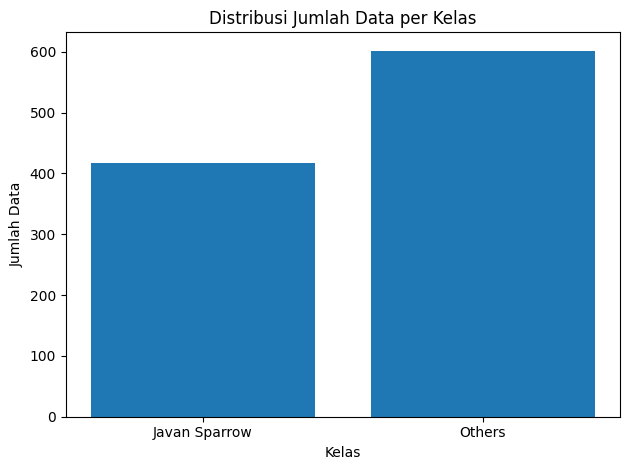

In [ ]:
data_root = stage_paths["fixedlen"]

class_counts = {}
for class_name in os.listdir(data_root):
    class_path = data_root / class_name
    if not os.path.isdir(class_path):
        continue
    class_counts[class_name] = len([
        f for f in os.listdir(class_path) if f.endswith('.wav')
    ])

print("Distribusi kelas (post-preprocessing):")
for k, v in class_counts.items():
    print(f"  {k}: {v}")

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Jumlah Data per Kelas")
plt.tight_layout()
plt.show()

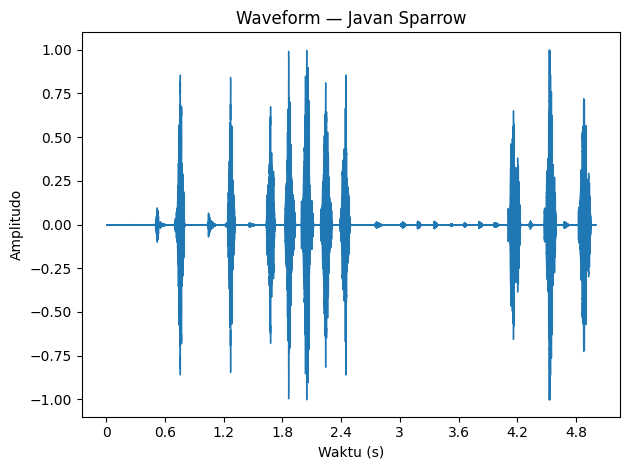

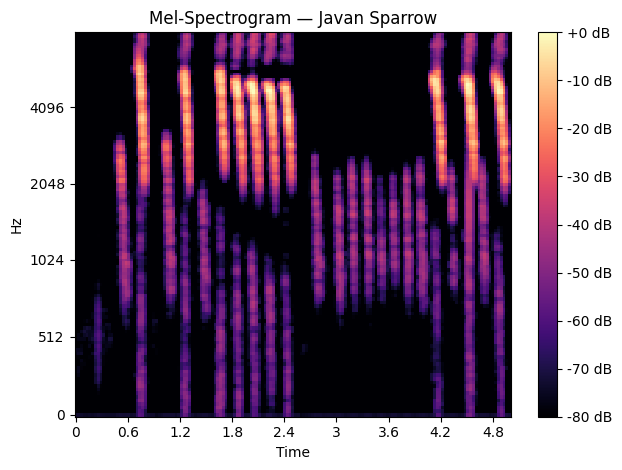

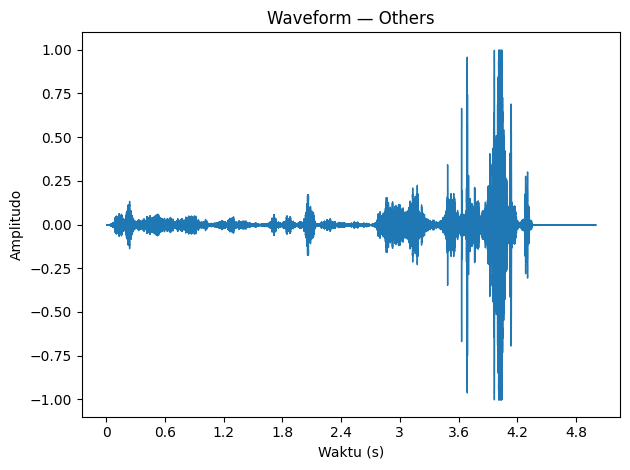

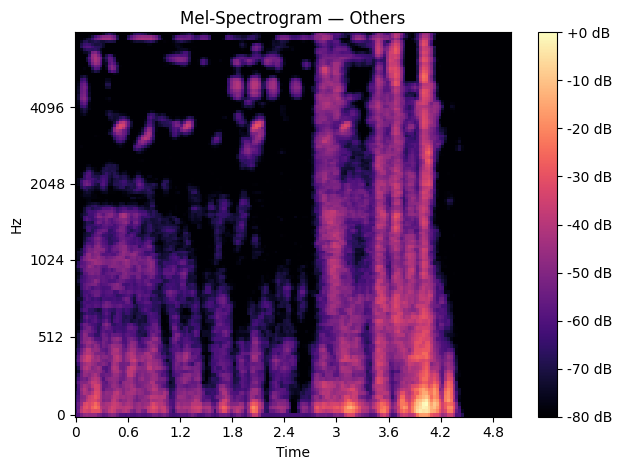

In [ ]:
# ── Visualisasi waveform dan Mel-spectrogram per kelas ────────────────────
for class_name in class_counts.keys():
    class_path = data_root / class_name
    sample_file = next(f for f in os.listdir(class_path) if f.endswith('.wav'))
    sample_path = class_path / sample_file
    y, sr = librosa.load(sample_path, sr=None)

    # Waveform
    plt.figure()
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform — {class_name}")
    plt.xlabel("Waktu (s)")
    plt.ylabel("Amplitudo")
    plt.tight_layout()
    plt.show()
    display(ipd.Audio(y, rate=sr))

    # Mel-spectrogram
    y_16k, _ = librosa.load(sample_path, sr=16000)
    mel_spec = librosa.feature.melspectrogram(y=y_16k, sr=16000, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure()
    librosa.display.specshow(mel_spec_db, sr=16000, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel-Spectrogram — {class_name}")
    plt.tight_layout()
    plt.show()

## Feature Engineering

Ekstraksi dua representasi fitur akustik (MFCC dan Mel-spectrogram) dari sinyal yang telah dipreparasi. Augmentasi *waveform* (*noise injection*, *time shifting*, *pitch shifting*) diterapkan khusus pada *split* pelatihan sebelum ekstraksi fitur agar variasi data tercermin secara konsisten pada kedua representasi turunan.

In [9]:
# ── Konfigurasi audio, fitur, dan augmentasi ──────────────────────────────
@dataclass(frozen=True)
class AudioCfg:
    sr: int = 16000
    duration_s: float = 5.0
    mono: bool = True


@dataclass(frozen=True)
class FeatureCfg:
    n_mfcc: int = 40
    n_mels: int = 128
    hop_length: int = 512
    n_fft: int = 2048
    fmax: int = 8000


@dataclass(frozen=True)
class AugCfg:
    enabled: bool = True
    noise_std: float = 0.005
    shift_max_frac: float = 0.10
    pitch_steps: int = 2


AUDIO_CFG   = AudioCfg(sr=16000, duration_s=5.0, mono=True)
FEATURE_CFG = FeatureCfg(n_mfcc=40, n_mels=128, hop_length=512, n_fft=2048, fmax=8000)
AUG_CFG     = AugCfg(enabled=True, noise_std=0.005, shift_max_frac=0.10, pitch_steps=2)

In [ ]:
# ── Train/Val/Test Split (stratified, bertahap 70/15/15) ──────────────────
SPLIT_CFG = {
    "test_size":               0.15,    # 15% dari seluruh data → test
    "val_size_within_trainval": 0.176,  # 17.6% dari trainval ≈ 15% dari total
}

filepaths, labels = [], []
for class_name in os.listdir(data_root):
    class_path = data_root / class_name
    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        if file.endswith('.wav'):
            filepaths.append(str(class_path / file))
            labels.append(class_name)

df_all = pd.DataFrame({"filepath": filepaths, "label": labels})
print(f"Total data: {len(df_all)}")
print(df_all["label"].value_counts())

train_val_df, test_df = train_test_split(
    df_all,
    test_size=SPLIT_CFG["test_size"],
    stratify=df_all["label"],
    random_state=SEED,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=SPLIT_CFG["val_size_within_trainval"],
    stratify=train_val_df["label"],
    random_state=SEED,
)

print("\nTrain:")
print(train_df["label"].value_counts())
print("\nValidation:")
print(val_df["label"].value_counts())
print("\nTest:")
print(test_df["label"].value_counts())

train_f, train_l = train_df["filepath"].tolist(), train_df["label"].tolist()
val_f,   val_l   = val_df["filepath"].tolist(),   val_df["label"].tolist()
test_f,  test_l  = test_df["filepath"].tolist(),  test_df["label"].tolist()

Total data: 1020
label
Others           602
Javan Sparrow    418
Name: count, dtype: int64

Train:
label
Others           422
Javan Sparrow    292
Name: count, dtype: int64

Validation:
label
Others           90
Javan Sparrow    63
Name: count, dtype: int64

Test:
label
Others           90
Javan Sparrow    63
Name: count, dtype: int64


In [ ]:
# ── Label mapping (digunakan lintas tahap) ────────────────────────────────
classes    = sorted(train_df["label"].astype(str).unique().tolist())
label2id   = {c: i for i, c in enumerate(classes)}
id2label   = {i: c for c, i in label2id.items()}
num_classes = len(classes)

label_meta = {
    "classes":     classes,
    "label2id":    label2id,
    "id2label":    {str(k): v for k, v in id2label.items()},
    "num_classes": num_classes,
}
label_meta_path = label_meta_dir / "label_meta.json"
with open(label_meta_path, "w") as f:
    json.dump(label_meta, f, indent=2)

print(f"\nLabel mapping disimpan ke: {label_meta_path}")
print(f"Kelas: {classes} | num_classes: {num_classes}")


Label mapping disimpan ke: /content/drive/MyDrive/UAJY/Gelatik Jawa/Meta/label_meta.json
Kelas: ['Javan Sparrow', 'Others'] | num_classes: 2


In [10]:
# ── Fungsi pendukung ekstraksi fitur ──────────────────────────────────────
def max_frames_for(duration_s: float, sr: int, hop_length: int) -> int:
    """Hitung jumlah frame maksimum yang dihasilkan untuk durasi sinyal tertentu."""
    n = int(sr * duration_s)
    return int(np.ceil(n / hop_length)) + 1


def load_fixed_length(fp: str, cfg: AudioCfg) -> np.ndarray:
    """Muat audio dan paksa panjang sinyal sesuai konfigurasi durasi."""
    y, _ = librosa.load(fp, sr=cfg.sr, mono=cfg.mono)
    target_len = int(cfg.sr * cfg.duration_s)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)


def augment_variants(
    y: np.ndarray,
    cfg_audio: AudioCfg,
    cfg_aug: AugCfg,
    rng: np.random.Generator,
) -> list:
    """
    Hasilkan empat varian sinyal: (orig, aug_noise, aug_shift, aug_pitch).
    Augmentasi dilakukan pada level waveform, sebelum ekstraksi fitur,
    agar kedua representasi fitur (MFCC dan Mel-spectrogram) menerima
    variasi data yang ekuivalen dari sumber sinyal yang sama.
    """
    variants = [("orig", y)]
    if not cfg_aug.enabled:
        return variants

    # 1. Noise injection — Gaussian white noise dengan deviasi standar kecil
    noise = cfg_aug.noise_std * rng.standard_normal(len(y)).astype(np.float32)
    variants.append(("aug_noise", (y + noise).astype(np.float32)))

    # 2. Time shifting — pergeseran sirkular acak hingga ±10% laju pencuplikan (≈ ±0,1 detik pada 16 kHz)
    max_shift = int(cfg_aug.shift_max_frac * cfg_audio.sr)
    shift = int(rng.integers(-max_shift, max_shift + 1))
    variants.append(("aug_shift", np.roll(y, shift).astype(np.float32)))

    # 3. Pitch shifting — pergeseran nada konstan sebesar +pitch_steps semitone
    y_pitch = librosa.effects.pitch_shift(y, sr=cfg_audio.sr, n_steps=cfg_aug.pitch_steps)
    variants.append(("aug_pitch", y_pitch.astype(np.float32)))

    return variants


def extract_features(
    y: np.ndarray,
    cfg_audio: AudioCfg,
    cfg_feat: FeatureCfg,
):
    """
    Ekstrak tiga representasi fitur dari satu sinyal audio:
        - mfcc_vec : vektor MFCC rata-rata (n_mfcc,)         → untuk Random Forest
        - mfcc_mat : matriks MFCC (n_mfcc, max_frames)        → untuk CNN+MFCC, LSTM+MFCC
        - S_db     : Mel-spectrogram log (n_mels, max_frames) → untuk CNN+MelSpec, LSTM+MelSpec
    Dimensi temporal seragam antara MFCC dan Mel-spectrogram untuk menjamin
    konsistensi panjang sekuens antar-varian eksperimen.
    """
    max_frames = max_frames_for(cfg_audio.duration_s, cfg_audio.sr, cfg_feat.hop_length)

    def _pad_or_trim(M: np.ndarray, target: int) -> np.ndarray:
        cur = M.shape[1]
        if cur > target:
            return M[:, :target]
        elif cur < target:
            return np.pad(M, ((0, 0), (0, target - cur)), mode="constant")
        return M

    # MFCC — agregasi rata-rata sepanjang frame untuk Random Forest
    mfcc_mat = librosa.feature.mfcc(
        y=y, sr=cfg_audio.sr,
        n_mfcc=cfg_feat.n_mfcc,
        n_fft=cfg_feat.n_fft,
        hop_length=cfg_feat.hop_length,
    ).astype(np.float32)
    mfcc_vec = mfcc_mat.mean(axis=1).astype(np.float32)
    mfcc_mat = _pad_or_trim(mfcc_mat, max_frames)

    # Mel-spectrogram log
    S = librosa.feature.melspectrogram(
        y=y, sr=cfg_audio.sr,
        n_mels=cfg_feat.n_mels,
        n_fft=cfg_feat.n_fft,
        hop_length=cfg_feat.hop_length,
        fmax=cfg_feat.fmax,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    S_db = _pad_or_trim(S_db, max_frames)

    return mfcc_vec, mfcc_mat, S_db


def save_npy_atomic(arr: np.ndarray, out_path: Path, max_retries: int = 3) -> None:
    """
    Simpan array NumPy secara atomic (write tmp → rename) untuk menghindari
    file korup pada penyimpanan lambat seperti Google Drive.
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = out_path.with_name(out_path.name + f".tmp_{int(time.time() * 1000)}.npy")
    np.save(str(tmp_path), arr)

    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            shutil.move(str(tmp_path), str(out_path))
            last_err = None
            break
        except OSError as e:
            last_err = e
            time.sleep(1.0 * attempt)

    if last_err is not None:
        if tmp_path.exists():
            tmp_path.unlink(missing_ok=True)
        raise last_err

In [ ]:
def run_feature_extraction(
    split_name: str,
    files: list,
    labels: list,
    out_root: Path,
    cfg_audio: AudioCfg,
    cfg_feat: FeatureCfg,
    cfg_aug: AugCfg,
    seed: int = 42,
    augment: bool = False,
):
    """
    Ekstrak dan persistensikan fitur untuk satu split (train/val/test).

    Output yang dihasilkan:
      - mfcc/<split>/features_mfcc_<split>.csv         → vektor MFCC (untuk RF)
      - mfcc_matrix/<split>/<label>/*.npy               → matriks MFCC (untuk CNN+MFCC, LSTM+MFCC)
      - mfcc_matrix/<split>/mfcc_<split>_refs.csv       → referensi path
      - spectrogram/<split>/<label>/*.npy               → Mel-spectrogram (untuk CNN+MelSpec, LSTM+MelSpec)
      - spectrogram/<split>/spectrogram_<split>_refs.csv → referensi path

    Augmentasi hanya diaktifkan ketika `augment=True`, yang berlaku khusus
    untuk split train. Split val dan test tetap dipertahankan dalam bentuk
    asli untuk menjaga objektivitas evaluasi.
    """
    rng = np.random.default_rng(seed)

    mfcc_dir     = out_root / "mfcc"         / split_name
    mfcc_mat_dir = out_root / "mfcc_matrix"  / split_name
    spec_dir     = out_root / "spectrogram"  / split_name
    training_logs_dir = out_root / "training_logs"  / split_name
    for d in (mfcc_dir, mfcc_mat_dir, spec_dir):
        d.mkdir(parents=True, exist_ok=True)

    mfcc_rows, mfcc_refs, spec_refs = [], [], []

    desc = f"{split_name}: ekstraksi" + ("+augmentasi" if augment else "")
    pbar = tqdm(list(zip(files, labels)), desc=desc, total=len(files))

    for fp, lbl in pbar:
        base = sanitize_filename(os.path.splitext(os.path.basename(fp))[0])
        y    = load_fixed_length(fp, cfg_audio)

        local_aug_cfg = cfg_aug if augment else AugCfg(enabled=False)
        variants      = augment_variants(y, cfg_audio, local_aug_cfg, rng)

        for aug_tag, yv in variants:
            mfcc_vec, mfcc_mat, S_db = extract_features(yv, cfg_audio, cfg_feat)
            name = f"{base}__{aug_tag}"

            # 1. Vektor MFCC untuk Random Forest
            mfcc_rows.append({
                **{f"feature_{i+1}": float(mfcc_vec[i]) for i in range(cfg_feat.n_mfcc)},
                "class":    lbl,
                "aug_type": aug_tag,
                "file_id":  base,
                "src_path": fp,
            })

            # 2. Matriks MFCC untuk CNN+MFCC dan LSTM+MFCC
            mfcc_npy_out = mfcc_mat_dir / lbl / f"{name}.npy"
            save_npy_atomic(mfcc_mat, mfcc_npy_out)
            mfcc_refs.append({
                "npy_path": str(mfcc_npy_out),
                "class":    lbl,
                "aug_type": aug_tag,
                "file_id":  base,
            })

            # 3. Mel-spectrogram untuk CNN+MelSpec dan LSTM+MelSpec
            spec_npy_out = spec_dir / lbl / f"{name}.npy"
            save_npy_atomic(S_db, spec_npy_out)
            spec_refs.append({
                "npy_path": str(spec_npy_out),
                "class":    lbl,
                "aug_type": aug_tag,
                "file_id":  base,
            })

        pbar.set_postfix(done=len(mfcc_rows))

    # Persist CSV untuk vektor MFCC
    df_mfcc = pd.DataFrame(mfcc_rows)
    feat_cols = [c for c in df_mfcc.columns if c.startswith("feature_")]
    df_mfcc[feat_cols]  = df_mfcc[feat_cols].astype("float32")
    df_mfcc["class"]    = df_mfcc["class"].astype("category")
    df_mfcc["aug_type"] = df_mfcc["aug_type"].astype("category")
    df_mfcc["file_id"]  = df_mfcc["file_id"].astype("category")
    out_csv = mfcc_dir / f"features_mfcc_{split_name}.csv"
    df_mfcc.sort_values(["class", "file_id", "aug_type"]).to_csv(out_csv, index=False)

    # Persist referensi npy untuk MFCC matrix dan Mel-spectrogram
    df_mfcc_refs = pd.DataFrame(mfcc_refs).sort_values(["class", "file_id", "aug_type"])
    df_mfcc_refs.to_csv(mfcc_mat_dir / f"mfcc_{split_name}_refs.csv", index=False)

    df_spec_refs = pd.DataFrame(spec_refs).sort_values(["class", "file_id", "aug_type"])
    df_spec_refs.to_csv(spec_dir / f"spectrogram_{split_name}_refs.csv", index=False)

    print(f"[{split_name}] MFCC vector    : {len(df_mfcc)} baris")
    print(f"[{split_name}] MFCC matrix    : {len(df_mfcc_refs)} file")
    print(f"[{split_name}] Mel-spectrogram: {len(df_spec_refs)} file")

    return df_mfcc, df_mfcc_refs, df_spec_refs

In [ ]:
# ── Eksekusi ekstraksi fitur untuk seluruh split ─────────────────────────
reset_dir(feature_root, force=True)
ckpt_dir.mkdir(parents=True, exist_ok=True)
training_log_dir.mkdir(parents=True, exist_ok=True)

run_feature_extraction(
    "train", train_f, train_l, feature_root,
    AUDIO_CFG, FEATURE_CFG, AUG_CFG, seed=SEED, augment=True,
)
run_feature_extraction(
    "val", val_f, val_l, feature_root,
    AUDIO_CFG, FEATURE_CFG, AUG_CFG, seed=SEED, augment=False,
)
run_feature_extraction(
    "test", test_f, test_l, feature_root,
    AUDIO_CFG, FEATURE_CFG, AUG_CFG, seed=SEED, augment=False,
)

train: ekstraksi+augmentasi:   0%|          | 0/714 [00:00<?, ?it/s]

[train] MFCC vector    : 2856 baris
[train] MFCC matrix    : 2856 file
[train] Mel-spectrogram: 2856 file


val: ekstraksi:   0%|          | 0/153 [00:00<?, ?it/s]

[val] MFCC vector    : 153 baris
[val] MFCC matrix    : 153 file
[val] Mel-spectrogram: 153 file


test: ekstraksi:   0%|          | 0/153 [00:00<?, ?it/s]

[test] MFCC vector    : 153 baris
[test] MFCC matrix    : 153 file
[test] Mel-spectrogram: 153 file


(      feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
 0   -342.336151   1.831686  28.063660  31.580818   7.774704   0.252837   
 1   -206.555130  62.323479 -14.538879   4.992407 -10.522116  -4.735023   
 2   -347.722198  26.661659  35.715317  13.356265  10.731310  12.845421   
 3   -230.901520  34.213520   3.527645  -4.291780  -2.205856   4.438431   
 4   -745.354370  -2.120458  -2.530932   0.595734  -0.606773  -0.307105   
 ..          ...        ...        ...        ...        ...        ...   
 148  -70.957878   7.777861   1.473029   8.363336   1.095100   5.638732   
 149 -225.658340  23.695824   9.524109 -16.983055 -16.848427  -9.526899   
 150  -63.735657   5.780325   4.200080   6.639131  -2.145241   3.482054   
 151 -559.071960   8.811517  28.827923  12.093059  11.349819   7.211171   
 152 -335.445953   4.379308  17.096863 -13.063166   2.432583  21.189232   
 
      feature_7  feature_8  feature_9  feature_10  ...  feature_35  feature_36  \
 0    16.008039 

## Model Configuration

Konfigurasi *hyperparameter* untuk tiga arsitektur (Random Forest, CNN, dan LSTM) beserta *callback* pelatihan umum. Konfigurasi dideklarasikan terpusat melalui *dictionary* untuk menjamin konsistensi dan mempermudah persistensi metadata pada tahap deployment.

In [ ]:
# ── Hyperparameter pelatihan dan callback (umum untuk seluruh model DL) ──
EXPERIMENT_CFG = {
    "batch_size": 32,
    "max_epochs": 100,
    "early_stopping_patience": 8,
    "reduce_lr_factor": 0.5,
    "reduce_lr_patience": 3,
    "reduce_lr_min": 1e-6,
    "cv_n_splits": 5,
}

In [ ]:
# ── Hyperparameter Random Forest ─────────────────────────────────────────
RF_FIXED = dict(
    max_features="sqrt",
    class_weight="balanced",
    random_state=SEED,
)

# Ruang pencarian hiperparameter untuk GridSearchCV
RF_PARAM_GRID = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2],
}

In [ ]:
# ── Hyperparameter CNN ───────────────────────────────────────────────────
CNN_CFG = dict(
    lr=1e-3,
    dropout=0.3,
    filters=(16, 32, 64),
    kernel_size=3,
)

In [ ]:
# ── Hyperparameter LSTM ──────────────────────────────────────────────────
LSTM_CFG = dict(
    lr=1e-3,
    dropout=0.3,
    units_1=64,
    units_2=32,
)

In [7]:
# ── Helper: muat label mapping ───────────────────────────────────────────
def load_label_meta():
    """Muat label mapping dari label_meta.json yang dihasilkan tahap split."""
    meta_path = label_meta_dir / "label_meta.json"
    if not meta_path.exists():
        raise FileNotFoundError(
            f"Label mapping tidak ditemukan: {meta_path}. "
            f"Jalankan tahap Train/Test Split (Sub-bab 3.2) terlebih dahulu."
        )
    with open(meta_path) as f:
        meta = json.load(f)
    classes_     = meta["classes"]
    label2id_    = meta["label2id"]
    id2label_    = {int(k): v for k, v in meta["id2label"].items()}
    num_classes_ = meta["num_classes"]
    return classes_, label2id_, id2label_, num_classes_

In [ ]:
# ── Helper: hitung bobot kelas seimbang ──────────────────────────────────
def compute_class_weight_dict(y_train_int: np.ndarray) -> dict:
    """
    Hitung bobot kelas berbasis inverse frequency. Berfungsi sebagai
    mekanisme penanganan class imbalance pada model deep learning,
    diterapkan melalui parameter `class_weight` pada Keras.fit().
    """
    unique_classes = np.unique(y_train_int)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=unique_classes,
        y=y_train_int,
    )
    return {int(c): float(w) for c, w in zip(unique_classes, weights)}

In [ ]:
# ── Helper: muat fitur dari hasil tahap Feature Engineering ──────────────
def load_mfcc_split(split: str, orig_only: bool = True):
    """Muat vektor MFCC dari CSV untuk split tertentu (digunakan oleh RF)."""
    fp = feature_root / "mfcc" / split / f"features_mfcc_{split}.csv"
    df = pd.read_csv(fp)
    if orig_only and "aug_type" in df.columns:
        df = df[df["aug_type"] == "orig"].reset_index(drop=True)
    feat_cols = [c for c in df.columns if c.startswith("feature_")]
    X = df[feat_cols].to_numpy(dtype=np.float32)
    y_labels = df["class"].astype(str)
    return X, y_labels


def load_feature_refs(feature_type: str, split: str, orig_only: bool = True):
    """
    Muat referensi path file .npy untuk fitur 2D (matriks MFCC atau
    Mel-spectrogram), yang akan digunakan oleh pipeline tf.data.
    """
    if feature_type not in ("mfcc_matrix", "spectrogram"):
        raise ValueError(
            f"feature_type harus 'mfcc_matrix' atau 'spectrogram', bukan: {feature_type!r}"
        )
    refs_prefix = "mfcc" if feature_type == "mfcc_matrix" else "spectrogram"
    fp = feature_root / feature_type / split / f"{refs_prefix}_{split}_refs.csv"
    if not fp.exists():
        raise FileNotFoundError(
            f"Refs CSV tidak ditemukan: {fp}. "
            f"Pastikan run_feature_extraction telah dijalankan untuk split '{split}'."
        )
    df = pd.read_csv(fp)
    if orig_only and "aug_type" in df.columns:
        df = df[df["aug_type"] == "orig"].reset_index(drop=True)
    if "npy_path" not in df.columns or "class" not in df.columns:
        raise ValueError(f"Refs CSV {fp} harus memiliki kolom 'npy_path' dan 'class'.")
    return df

In [ ]:
# ── Pipeline tf.data builder untuk CNN dan LSTM ──────────────────────────
def make_cnn_ds(
    df: pd.DataFrame,
    npy_shape: tuple,
    label2id: dict,
    batch: int = 32,
    shuffle: bool = False,
) -> tf.data.Dataset:
    """
    Pipeline tf.data untuk CNN. Input akhir: tensor (H, W, 1) dari file
    .npy berukuran (H, W). Channel tunggal ditambahkan via expand_dims.
    """
    paths  = df["npy_path"].astype(str).to_numpy()
    labels = df["class"].astype(str).map(label2id).to_numpy(dtype=np.int32)
    h, w   = npy_shape

    def _load_npy(p: tf.Tensor) -> tf.Tensor:
        def _read(path_bytes):
            arr = np.load(path_bytes.decode("utf-8")).astype(np.float32)
            return np.expand_dims(arr, axis=-1)
        x = tf.numpy_function(_read, [p], Tout=tf.float32)
        x.set_shape([h, w, 1])
        return x

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=SEED, reshuffle_each_iteration=True)

    def _map(p, y):
        return _load_npy(p), tf.cast(y, tf.int32)

    return ds.map(_map, num_parallel_calls=AUTOTUNE).batch(batch).prefetch(AUTOTUNE)


def make_lstm_ds(
    df: pd.DataFrame,
    npy_shape: tuple,
    label2id: dict,
    batch: int = 32,
    shuffle: bool = False,
) -> tf.data.Dataset:
    """
    Pipeline tf.data untuk LSTM. Input akhir: tensor (T, F) dengan T = jumlah
    frame dan F = jumlah fitur per frame. Matriks (F, T) dari file .npy
    di-transpose menjadi (T, F) agar sumbu temporal menjadi dimensi pertama.
    """
    paths  = df["npy_path"].astype(str).to_numpy()
    labels = df["class"].astype(str).map(label2id).to_numpy(dtype=np.int32)
    h, w   = npy_shape  # (F, T)

    def _load_npy(p: tf.Tensor) -> tf.Tensor:
        def _read(path_bytes):
            arr = np.load(path_bytes.decode("utf-8")).astype(np.float32)
            return arr.T  # transpose ke (T, F)
        x = tf.numpy_function(_read, [p], Tout=tf.float32)
        x.set_shape([w, h])  # (T, F)
        return x

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=SEED, reshuffle_each_iteration=True)

    def _map(p, y):
        return _load_npy(p), tf.cast(y, tf.int32)

    return ds.map(_map, num_parallel_calls=AUTOTUNE).batch(batch).prefetch(AUTOTUNE)

In [ ]:
# ── Arsitektur model CNN ─────────────────────────────────────────────────
def build_cnn(
    input_shape: tuple,
    num_classes: int,
    cfg: dict = CNN_CFG,
    name: str = "CNN",
) -> tf.keras.Model:
    """
    Bangun CNN untuk klasifikasi audio berbasis representasi 2D.

    Arsitektur:
        3× [Conv2D → BatchNorm → ReLU → MaxPool2D]
        → GlobalAveragePooling2D → Dropout → Dense(softmax)

    Arsitektur dipertahankan identik antara CNN+MFCC dan CNN+MelSpec; yang
    berbeda hanyalah dimensi input. Hal ini memastikan perbedaan performa
    yang teramati pada tahap evaluasi dapat diatribusikan pada perbedaan
    representasi fitur, bukan pada perbedaan arsitektur.
    """
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(cfg["filters"][0], cfg["kernel_size"], padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D((2, 2))(x)

    x = layers.Conv2D(cfg["filters"][1], cfg["kernel_size"], padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D((2, 2))(x)

    x = layers.Conv2D(cfg["filters"][2], cfg["kernel_size"], padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dropout(cfg["dropout"])(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg["lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
# ── Arsitektur model LSTM ────────────────────────────────────────────────
def build_lstm(
    input_shape: tuple,
    num_classes: int,
    cfg: dict = LSTM_CFG,
    name: str = "LSTM",
) -> tf.keras.Model:
    """
    Bangun LSTM dua-lapis untuk klasifikasi audio berbasis sekuens temporal.

    Arsitektur:
        Masking(mask_value=0.0) → LSTM(units_1, return_sequences=True)
                                → LSTM(units_2)
                                → Dropout → Dense(softmax)

    Lapisan Masking diperlukan karena tahap normalisasi durasi (Sub-bab
    3.2.1.2) menambahkan silence padding bernilai nol pada sinyal yang
    lebih pendek dari durasi target. Tanpa Masking, LSTM akan memperlakukan
    frame padding sebagai bagian dari sinyal vokalisasi dan berpotensi
    mempelajari pola palsu yang mendistorsi hidden state.
    """
    inp = layers.Input(shape=input_shape)

    x = layers.Masking(mask_value=0.0)(inp)
    x = layers.LSTM(cfg["units_1"], return_sequences=True)(x)
    x = layers.LSTM(cfg["units_2"])(x)
    x = layers.Dropout(cfg["dropout"])(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg["lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
# ── Callback kustom: log learning rate aktual per epoch ──────────────────
class LearningRateLogger(callbacks.Callback):
    """Catat learning rate aktual ke logs setelah setiap epoch."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        opt = self.model.optimizer
        lr  = opt.learning_rate
        if callable(lr):
            lr_value = float(K.get_value(lr(opt.iterations)))
        else:
            lr_value = float(K.get_value(lr))
        logs["lr"] = lr_value


def make_callbacks(ckpt_path: str, csv_log_path: str) -> list:
    """
    Susun lima callback standar untuk pelatihan deep learning.

    Urutan callback penting:
      1. LearningRateLogger → menulis 'lr' ke logs epoch berjalan,
         sehingga CSVLogger dan ModelCheckpoint berikutnya dapat membaca
         nilai lr yang sudah di-update oleh ReduceLROnPlateau.
      2. CSVLogger          → persistensi metrik per epoch ke disk
      3. EarlyStopping      → hentikan training bila val_accuracy stagnan
      4. ModelCheckpoint    → simpan bobot terbaik berdasarkan val_accuracy
      5. ReduceLROnPlateau  → turunkan lr bila val_loss stagnan
    """
    return [
        LearningRateLogger(),
        callbacks.CSVLogger(csv_log_path, append=False),
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=EXPERIMENT_CFG["early_stopping_patience"],
            restore_best_weights=True,
        ),
        callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_accuracy",
            save_best_only=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=EXPERIMENT_CFG["reduce_lr_factor"],
            patience=EXPERIMENT_CFG["reduce_lr_patience"],
            min_lr=EXPERIMENT_CFG["reduce_lr_min"],
        ),
    ]

In [ ]:
# ── Utilitas evaluasi dan visualisasi (digunakan oleh Sub-bab 4.3.5) ─
def evaluate_classifier(
    name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    classes: list,
    inference_stats: dict,
    *,
    plot_cm: bool = True,
    print_report: bool = True,
) -> dict:
    """
    Hitung dan tampilkan metrik klasifikasi dan statistik waktu inferensi.

    Args:
        name            : Nama kombinasi eksperimen (mis. "RF + MFCC").
        y_true, y_pred  : Label aktual dan prediksi.
        classes         : Daftar nama kelas (untuk classification_report).
        inference_stats : Output dari measure_inference_per_sample(),
                          memuat mean_ms, std_ms, median_ms, p95_ms, dst.
        plot_cm         : Plot confusion matrix.
        print_report    : Print classification report ke stdout.
    """
    n    = len(y_true)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    result = {
        "name":             name,
        "accuracy":         float(acc),
        "precision_macro":  float(prec),
        "recall_macro":     float(rec),
        "f1_macro":         float(f1),
        "infer_ms_mean":    inference_stats["mean_ms"],
        "infer_ms_std":     inference_stats["std_ms"],
        "infer_ms_median":  inference_stats["median_ms"],
        "infer_ms_p95":     inference_stats["p95_ms"],
        "infer_ms_min":     inference_stats["min_ms"],
        "infer_ms_max":     inference_stats["max_ms"],
        "n_warmup":         inference_stats["n_warmup"],
        "n_timed":          inference_stats["n_timed"],
        "n_test":           int(n),
    }

    if print_report:
        print(f"\n{'=' * 60}")
        print(f"  {name} — Evaluasi Test Set (Final)")
        print(f"{'=' * 60}")
        print(f"  Accuracy            : {acc:.4f}")
        print(f"  Precision (macro)   : {prec:.4f}")
        print(f"  Recall (macro)      : {rec:.4f}")
        print(f"  F1-score (macro)    : {f1:.4f}")
        print(f"  Inferensi/sampel:")
        print(f"    Mean ± Std        : {inference_stats['mean_ms']:.4f} ± {inference_stats['std_ms']:.4f} ms")
        print(f"    Median            : {inference_stats['median_ms']:.4f} ms")
        print(f"    P95               : {inference_stats['p95_ms']:.4f} ms")
        print(f"    Min / Max         : {inference_stats['min_ms']:.4f} / {inference_stats['max_ms']:.4f} ms")
        print(f"    Warmup / Timed    : {inference_stats['n_warmup']} / {inference_stats['n_timed']} sampel")
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    if plot_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
        )
        plt.xlabel("Label Prediksi")
        plt.ylabel("Label Aktual")
        plt.title(f"{name} — Confusion Matrix (Test Set)")
        plt.tight_layout()
        plt.show()

    return result


def plot_training_history(history, title_prefix: str) -> None:
    """
    Plot kurva loss, accuracy, dan learning rate (skala log) dalam satu
    figure tiga panel horizontal. Skala log pada panel learning rate
    membuat penurunan multiplikatif (faktor 0.5) tetap terbaca jelas.
    """
    h      = history.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, h["loss"],     label="Train",      linewidth=1.5)
    axes[0].plot(epochs, h["val_loss"], label="Validation", linewidth=1.5)
    axes[0].set_title(f"{title_prefix} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h["accuracy"],     label="Train",      linewidth=1.5)
    axes[1].plot(epochs, h["val_accuracy"], label="Validation", linewidth=1.5)
    axes[1].set_title(f"{title_prefix} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if "lr" in h:
        axes[2].plot(epochs, h["lr"], color="tab:red", linewidth=1.5)
        axes[2].set_yscale("log")
        axes[2].set_title(f"{title_prefix} — Learning Rate")
        axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate (log)")
        axes[2].grid(True, alpha=0.3, which="both")
    else:
        axes[2].axis("off")
        axes[2].set_title(f"{title_prefix} — LR (not logged)")

    plt.tight_layout()
    plt.show()


def keras_predict_labels(model: tf.keras.Model, ds: tf.data.Dataset):
    """Prediksi batch pada seluruh dataset; kembalikan (y_true, y_pred) sebagai array 1D."""
    y_true_list, y_pred_list = [], []
    for xb, yb in ds:
        preds = model.predict(xb, verbose=0).argmax(axis=1)
        y_true_list.append(yb.numpy())
        y_pred_list.append(preds)
    return np.concatenate(y_true_list), np.concatenate(y_pred_list)


def materialize_dataset(ds: tf.data.Dataset):
    """
    Konsolidasi seluruh tf.data.Dataset menjadi (X, y) NumPy array.
    Diperlukan untuk pengukuran inferensi per-sampel, yang menuntut
    akses ke tensor individual tanpa batching.
    """
    xs, ys = [], []
    for xb, yb in ds:
        xs.append(xb.numpy())
        ys.append(yb.numpy())
    X = np.concatenate(xs, axis=0)
    y = np.concatenate(ys, axis=0)
    return X, y


def measure_inference_per_sample(
    model,
    samples,
    *,
    model_kind: str,
    n_warmup: int = 10,
) -> dict:
    """
    Ukur waktu inferensi per sampel (single-sample latency) untuk simulasi
    skenario deployment di mana satu file audio masuk dan satu prediksi
    dihasilkan, sebagaimana terjadi pada aplikasi inferensi Streamlit.

    Prosedur:
      1. Warmup: lakukan n_warmup prediksi pada sampel pertama untuk
         memicu graph compilation TensorFlow dan stabilisasi GPU/CPU.
      2. Pengukuran: untuk setiap sampel pada `samples`, ukur waktu
         model.predict(satu_sampel) menggunakan time.perf_counter().
      3. Statistik: hitung mean, std, median, dan persentil ke-95 dari
         seluruh waktu pengukuran, dalam satuan milidetik.

    Args:
        model      : Random Forest (sklearn) atau Keras model.
        samples    : Untuk RF, ndarray (N, n_features). Untuk Keras,
                     ndarray (N, ...) yang sudah dimuat ke memori.
        model_kind : 'rf' untuk Random Forest, 'keras' untuk Keras model.
        n_warmup   : Jumlah warmup runs sebelum pengukuran dimulai.

    Returns:
        dict dengan field: mean_ms, std_ms, median_ms, p95_ms,
                           min_ms, max_ms, n_warmup, n_timed.
    """
    if model_kind not in ("rf", "keras"):
        raise ValueError(f"model_kind harus 'rf' atau 'keras', bukan: {model_kind!r}")

    if len(samples) == 0:
        raise ValueError("samples tidak boleh kosong.")

    # Tentukan fungsi predict berdasarkan jenis model
    if model_kind == "rf":
        # RF.predict mengharapkan input 2D (1, n_features)
        def _predict_one(x):
            x_batched = x.reshape(1, -1)
            return model.predict(x_batched)
    else:
        # Keras.predict mengharapkan batch sebagai dimensi pertama
        def _predict_one(x):
            x_batched = np.expand_dims(x, axis=0)
            return model.predict(x_batched, verbose=0)

    # Tahap 1: Warmup
    warmup_sample = samples[0]
    for _ in range(n_warmup):
        _ = _predict_one(warmup_sample)

    # Tahap 2: Pengukuran per-sampel
    times_ms = []
    for x in samples:
        t0 = time.perf_counter()
        _ = _predict_one(x)
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000.0)

    times_arr = np.asarray(times_ms, dtype=np.float64)

    return {
        "mean_ms":   float(times_arr.mean()),
        "std_ms":    float(times_arr.std(ddof=1)) if len(times_arr) > 1 else 0.0,
        "median_ms": float(np.median(times_arr)),
        "p95_ms":    float(np.percentile(times_arr, 95)),
        "min_ms":    float(times_arr.min()),
        "max_ms":    float(times_arr.max()),
        "n_warmup":  int(n_warmup),
        "n_timed":   int(len(times_arr)),
    }


def save_training_artifacts(
    history,
    model_name: str,
    output_dir: Path,
    monitor: str = "val_accuracy",
) -> dict:
    """
    Persist riwayat training lengkap ke JSON dan kembalikan ringkasan
    best epoch (untuk dikonsolidasikan antar model pada Sub-bab 4 / 5.2).
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    h = history.history

    if monitor not in h:
        raise ValueError(
            f"Monitor '{monitor}' tidak ada di history. Kunci tersedia: {list(h.keys())}"
        )

    monitor_values = np.asarray(h[monitor], dtype=np.float64)
    best_idx = int(np.argmin(monitor_values) if "loss" in monitor
                   else np.argmax(monitor_values))

    summary = {
        "model_name":          model_name,
        "total_epochs":        len(monitor_values),
        "best_epoch":          best_idx + 1,
        "monitor":             monitor,
        "best_val_accuracy":   float(h["val_accuracy"][best_idx]),
        "best_val_loss":       float(h["val_loss"][best_idx]),
        "best_train_accuracy": float(h["accuracy"][best_idx]),
        "best_train_loss":     float(h["loss"][best_idx]),
        "initial_lr":          float(h["lr"][0])  if "lr" in h else None,
        "final_lr":            float(h["lr"][-1]) if "lr" in h else None,
    }

    history_serializable = {k: [float(v) for v in vals] for k, vals in h.items()}
    history_path = output_dir / f"{model_name}_history.json"
    with open(history_path, "w") as f:
        json.dump({"summary": summary, "history": history_serializable}, f, indent=2)

    print(f"\n{'─' * 60}")
    print(f"  {model_name} — Training Summary")
    print(f"{'─' * 60}")
    print(f"  Total epochs             : {summary['total_epochs']}")
    print(f"  Best epoch (by {monitor}) : {summary['best_epoch']}")
    print(f"  Best val_accuracy        : {summary['best_val_accuracy']:.4f}")
    print(f"  Best val_loss            : {summary['best_val_loss']:.4f}")
    print(f"  Train accuracy @ best    : {summary['best_train_accuracy']:.4f}")
    print(f"  Train loss @ best        : {summary['best_train_loss']:.4f}")
    if summary["initial_lr"] is not None:
        print(f"  Initial LR               : {summary['initial_lr']:.2e}")
        print(f"  Final LR                 : {summary['final_lr']:.2e}")
    print(f"  History JSON             : {history_path}")

    return summary

In [ ]:
# ── Muat fitur terjadwal untuk seluruh model dan inisialisasi label ──────
classes, label2id, id2label, num_classes = load_label_meta()

# Untuk Random Forest (vektor MFCC tabular)
X_train_raw, y_train_labels = load_mfcc_split("train", orig_only=False)
X_val_raw,   y_val_labels   = load_mfcc_split("val",   orig_only=True)
X_test_raw,  y_test_labels  = load_mfcc_split("test",  orig_only=True)

X_train = X_train_raw
y_train = y_train_labels.map(label2id).to_numpy(dtype=np.int32)
X_val   = X_val_raw
y_val   = y_val_labels.map(label2id).to_numpy(dtype=np.int32)
X_test  = X_test_raw
y_test  = y_test_labels.map(label2id).to_numpy(dtype=np.int32)

print(f"Kelas: {classes} | num_classes: {num_classes}")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

BATCH = EXPERIMENT_CFG["batch_size"]

# Akumulator hasil eksperimen (digunakan pada Sub-bab 4 / 5.2)
results        = []
dl_summaries   = []

Kelas: ['Javan Sparrow', 'Others'] | num_classes: 2
X_train: (2856, 40)  X_val: (153, 40)  X_test: (153, 40)


## Model Validation

 Strategi *cross validation* dipilih untuk RF karena waktu pelatihan singkat; model deep learning menggunakan strategi *hold-out validation* pada *split* validasi yang sudah ditetapkan.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n" + "=" * 70)
print("Model Validation — Random Forest: GridSearchCV (Stratified 5-Fold)")
print("=" * 70)

X_train_orig, y_train_orig_labels = load_mfcc_split("train", orig_only=True)
y_train_orig = y_train_orig_labels.map(label2id).to_numpy(dtype=np.int32)

skf = StratifiedKFold(
    n_splits=EXPERIMENT_CFG["cv_n_splits"],
    shuffle=True,
    random_state=SEED,
)

scoring = {
    "accuracy":        "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro":    "recall_macro",
    "f1_macro":        "f1_macro",
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(**RF_FIXED),
    param_grid=RF_PARAM_GRID,
    scoring=scoring,
    refit="f1_macro",
    cv=skf,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train_orig, y_train_orig)

best_params = grid.best_params_
best_score  = grid.best_score_
print("\nParameter terbaik:", best_params)
print(f"Skor CV terbaik (f1_macro): {best_score:.4f}")

best_idx = grid.best_index_
n_splits = skf.get_n_splits()
cv_rows = []
for k in range(n_splits):
    cv_rows.append({
        "fold":            k + 1,
        "accuracy":        grid.cv_results_[f"split{k}_test_accuracy"][best_idx],
        "precision_macro": grid.cv_results_[f"split{k}_test_precision_macro"][best_idx],
        "recall_macro":    grid.cv_results_[f"split{k}_test_recall_macro"][best_idx],
        "f1_macro":        grid.cv_results_[f"split{k}_test_f1_macro"][best_idx],
    })
cv_df = pd.DataFrame(cv_rows)
print("\n=== RF — Per-fold (konfigurasi terpilih) ===")
print(cv_df.mean(numeric_only=True).to_string())
print(f"Std F1-macro antar-fold: {cv_df['f1_macro'].std():.4f}")

cv_summary_path = training_log_dir / "rf_cv_summary.csv"
cv_df.to_csv(cv_summary_path, index=False)
pd.DataFrame([best_params]).to_csv(training_log_dir / "rf_best_params.csv", index=False)
print(f"Hasil CV disimpan ke: {cv_summary_path}")


Model Validation — Random Forest: GridSearchCV (Stratified 5-Fold)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Parameter terbaik: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Skor CV terbaik (f1_macro): 0.9133

=== RF — Per-fold (konfigurasi terpilih) ===
fold               3.000000
accuracy           0.917374
precision_macro    0.920718
recall_macro       0.908447
f1_macro           0.913316
Std F1-macro antar-fold: 0.0102
Hasil CV disimpan ke: /content/drive/MyDrive/UAJY/Gelatik Jawa/Features/training_logs/rf_cv_summary.csv


## Model Training

Pelatihan lima kombinasi eksperimen secara berurutan: (1) RF + MFCC, (2) CNN + Mel-Spectrogram, (3) CNN + MFCC, (4) LSTM + Mel-Spectrogram, (5) LSTM + MFCC. Setiap kombinasi menghasilkan model terlatih, metrik klasifikasi pada *test set*, dan pengukuran *single-sample latency* untuk kebutuhan evaluasi komparatif pada Bab V.

### 4.3.5.1 RF + MFCC


4.3.5.1 Training: RF + MFCC

Mengukur waktu inferensi per-sampel...

  RF + MFCC — Evaluasi Test Set (Final)
  Accuracy            : 0.9542
  Precision (macro)   : 0.9538
  Recall (macro)      : 0.9516
  F1-score (macro)    : 0.9527
  Inferensi/sampel:
    Mean ± Std        : 45.6860 ± 5.6750 ms
    Median            : 44.2871 ms
    P95               : 55.6596 ms
    Min / Max         : 32.6713 / 59.8211 ms
    Warmup / Timed    : 10 / 153 sampel

Classification Report:
               precision    recall  f1-score   support

Javan Sparrow       0.95      0.94      0.94        63
       Others       0.96      0.97      0.96        90

     accuracy                           0.95       153
    macro avg       0.95      0.95      0.95       153
 weighted avg       0.95      0.95      0.95       153



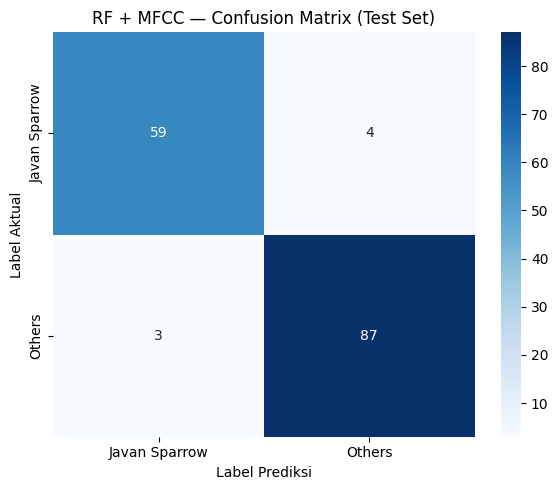

In [ ]:
print("\n" + "=" * 70)
print("4.3.5.1 Training: RF + MFCC")
print("=" * 70)

X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

rf_final = RandomForestClassifier(**RF_FIXED, **best_params, n_jobs=-1)
rf_final.fit(X_trainval, y_trainval)

y_pred_rf = rf_final.predict(X_test)

print("\nMengukur waktu inferensi per-sampel...")
inference_stats_rf = measure_inference_per_sample(
    model=rf_final,
    samples=X_test,
    model_kind="rf",
    n_warmup=10,
)

rf_result = evaluate_classifier(
    name="RF + MFCC",
    y_true=y_test,
    y_pred=y_pred_rf,
    classes=classes,
    inference_stats=inference_stats_rf,
)
results.append(rf_result)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the 

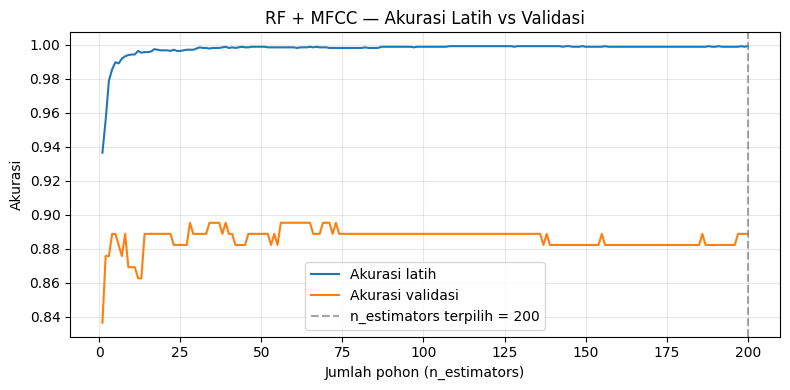

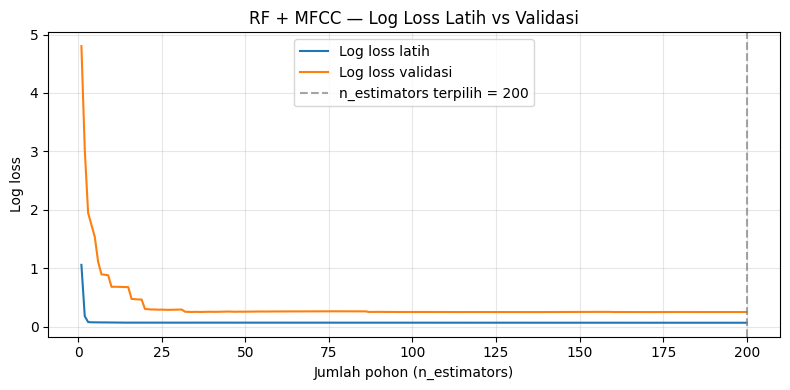

In [ ]:
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

base_cfg  = {**RF_FIXED, **{k: v for k, v in best_params.items() if k != "n_estimators"}}
MAX_TREES = max(int(best_params["n_estimators"]), 200)
n_list    = np.arange(1, MAX_TREES + 1)

all_class_ids = np.unique(y_train)

def _proba_safe(model, X):
    p = model.predict_proba(X)
    p = np.clip(p, 1e-15, 1.0)
    return p / p.sum(axis=1, keepdims=True)

rf_curve = RandomForestClassifier(
    **base_cfg,
    n_estimators=1,
    warm_start=True,
    n_jobs=-1,
)

train_acc, val_acc, train_loss, val_loss = [], [], [], []
for n in n_list:
    rf_curve.set_params(n_estimators=n)
    rf_curve.fit(X_train, y_train)
    train_acc.append(rf_curve.score(X_train, y_train))
    val_acc.append(rf_curve.score(X_val, y_val))
    train_loss.append(log_loss(y_train, _proba_safe(rf_curve, X_train), labels=all_class_ids))
    val_loss.append(log_loss(y_val,   _proba_safe(rf_curve, X_val),   labels=all_class_ids))

# ── Plot akurasi ──
plt.figure(figsize=(8, 4))
plt.plot(n_list, train_acc, label="Akurasi latih")
plt.plot(n_list, val_acc,   label="Akurasi validasi")
plt.axvline(best_params["n_estimators"], ls="--", c="gray", alpha=0.7,
            label=f"n_estimators terpilih = {best_params['n_estimators']}")
plt.xlabel("Jumlah pohon (n_estimators)"); plt.ylabel("Akurasi")
plt.title("RF + MFCC — Akurasi Latih vs Validasi")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(training_log_dir / "rf_learning_curve_acc.png", dpi=150)
plt.show()

# ── Plot log loss ──
plt.figure(figsize=(8, 4))
plt.plot(n_list, train_loss, label="Log loss latih")
plt.plot(n_list, val_loss,   label="Log loss validasi")
plt.axvline(best_params["n_estimators"], ls="--", c="gray", alpha=0.7,
            label=f"n_estimators terpilih = {best_params['n_estimators']}")
plt.xlabel("Jumlah pohon (n_estimators)"); plt.ylabel("Log loss")
plt.title("RF + MFCC — Log Loss Latih vs Validasi")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(training_log_dir / "rf_learning_curve_logloss.png", dpi=150)
plt.show()

### 4.3.5.2 CNN + Mel-Spectrogram


4.3.5.2 Training: CNN + Mel-spectrogram
Mel-spectrogram shape: (128, 158)


Model: "CNN_MelSpec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 158, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 158, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 158, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 158, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 79, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 79, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 79, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,874 (93.26 KB)

 Trainable params: 23,650 (92.38 KB)

 Non-trainable params: 224 (896.00 B)

CNN + MelSpec — class weights: {0: 1.2226027397260273, 1: 0.8459715639810427}
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - accuracy: 0.7104 - loss: 0.5680 - val_accuracy: 0.5882 - val_loss: 0.7474 - lr: 0.0010 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.8211 - loss: 0.4184 - val_accuracy: 0.6667 - val_loss: 0.6378 - lr: 0.0010 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.8673 - loss: 0.3354 - val_accuracy: 0.6275 - val_loss: 0.7678 - lr: 0.0010 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9044 - loss: 0.2738 - val_accuracy: 0.4118 - val_loss: 2.2455 - lr: 0.0010 - learning_rate: 0.0010
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.9023 - loss: 0.2578 - val_accuracy: 0.8562 - val_loss: 0.3354 - lr: 0.0010 - learning_rate: 0.0010
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.9072 - loss: 0.2418

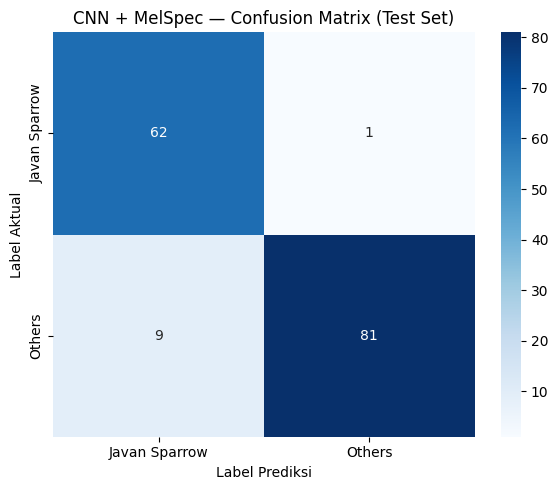

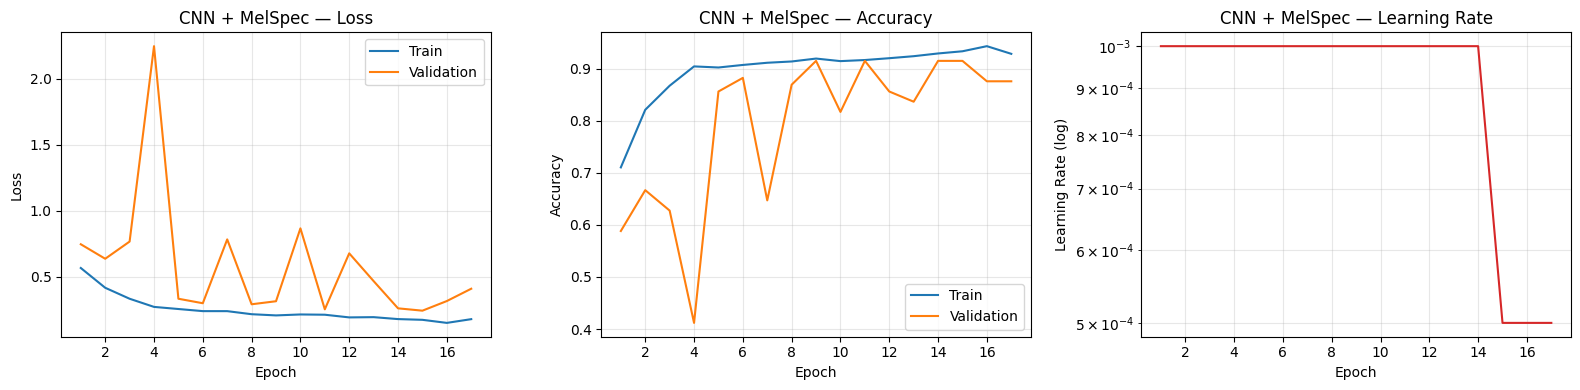

In [ ]:
print("\n" + "=" * 70)
print("4.3.5.2 Training: CNN + Mel-spectrogram")
print("=" * 70)

spec_train_refs = load_feature_refs("spectrogram", "train", orig_only=False)
spec_val_refs   = load_feature_refs("spectrogram", "val",   orig_only=True)
spec_test_refs  = load_feature_refs("spectrogram", "test",  orig_only=True)

sample_spec_path = Path(spec_train_refs.iloc[0]["npy_path"])
if not sample_spec_path.exists():
    raise FileNotFoundError(f"Contoh file .npy tidak ditemukan: {sample_spec_path}")
S_sample = np.load(sample_spec_path)
n_mels, n_frames = S_sample.shape
print(f"Mel-spectrogram shape: ({n_mels}, {n_frames})")

train_cnn_melspec_ds = make_cnn_ds(spec_train_refs, (n_mels, n_frames), label2id, batch=BATCH, shuffle=True)
val_cnn_melspec_ds   = make_cnn_ds(spec_val_refs,   (n_mels, n_frames), label2id, batch=BATCH, shuffle=False)
test_cnn_melspec_ds  = make_cnn_ds(spec_test_refs,  (n_mels, n_frames), label2id, batch=BATCH, shuffle=False)

# Instansiasi model dan callback
K.clear_session()
cnn_melspec = build_cnn((n_mels, n_frames, 1), num_classes, cfg=CNN_CFG, name="CNN_MelSpec")
cnn_melspec.summary()

y_train_int_cnn_melspec  = spec_train_refs["class"].astype(str).map(label2id).to_numpy(dtype=np.int32)
class_weight_cnn_melspec = compute_class_weight_dict(y_train_int_cnn_melspec)
print(f"CNN + MelSpec — class weights: {class_weight_cnn_melspec}")

ckpt_path_cnn_melspec = str(ckpt_dir / "cnn_melspec_best.keras")
csv_log_cnn_melspec   = str(training_log_dir / "cnn_melspec_epochs.csv")
cb_cnn_melspec        = make_callbacks(ckpt_path_cnn_melspec, csv_log_cnn_melspec)

# Training
history_cnn_melspec = cnn_melspec.fit(
    train_cnn_melspec_ds,
    validation_data=val_cnn_melspec_ds,
    epochs=EXPERIMENT_CFG["max_epochs"],
    callbacks=cb_cnn_melspec,
    class_weight=class_weight_cnn_melspec,
    verbose=1,
)
summary_cnn_melspec = save_training_artifacts(history_cnn_melspec, "cnn_melspec", training_log_dir)
dl_summaries.append(summary_cnn_melspec)

# Prediksi label test set (untuk menghitung metrik klasifikasi)
y_true_cnn_melspec, y_pred_cnn_melspec = keras_predict_labels(cnn_melspec, test_cnn_melspec_ds)

# Pengukuran waktu inferensi per-sampel (single-sample latency)
print("\nMengukur waktu inferensi per-sampel...")
X_test_cnn_melspec, _ = materialize_dataset(test_cnn_melspec_ds)
inference_stats_cnn_melspec = measure_inference_per_sample(
    model=cnn_melspec,
    samples=X_test_cnn_melspec,
    model_kind="keras",
    n_warmup=10,
)

cnn_melspec_result = evaluate_classifier(
    name="CNN + MelSpec",
    y_true=y_true_cnn_melspec,
    y_pred=y_pred_cnn_melspec,
    classes=classes,
    inference_stats=inference_stats_cnn_melspec,
)
results.append(cnn_melspec_result)
plot_training_history(history_cnn_melspec, "CNN + MelSpec")

### 4.3.5.3 CNN + MFCC


4.3.5.3 Training: CNN + MFCC
MFCC matrix shape: (40, 158)


Model: "CNN_MFCC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 158, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 158, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 158, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 40, 158, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 79, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 79, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 79, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 20, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 10, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,874 (93.26 KB)

 Trainable params: 23,650 (92.38 KB)

 Non-trainable params: 224 (896.00 B)

CNN + MFCC — class weights: {0: 1.2226027397260273, 1: 0.8459715639810427}
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.8337 - loss: 0.3941 - val_accuracy: 0.7190 - val_loss: 0.5034 - lr: 0.0010 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9051 - loss: 0.2535 - val_accuracy: 0.9216 - val_loss: 0.3246 - lr: 0.0010 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.9240 - loss: 0.2026 - val_accuracy: 0.8562 - val_loss: 0.3844 - lr: 0.0010 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.9317 - loss: 0.1868 - val_accuracy: 0.8954 - val_loss: 0.2699 - lr: 0.0010 - learning_rate: 0.0010
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9289 - loss: 0.1810 - val_accuracy: 0.8235 - val_loss: 0.4223 - lr: 0.0010 - learning_rate: 0.0010
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.9384 - loss: 0.1620 - 

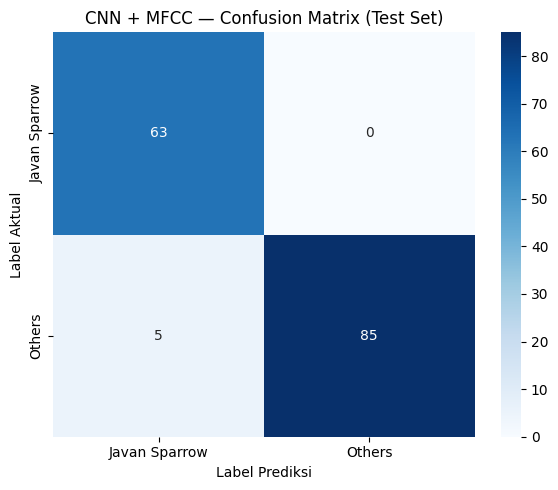

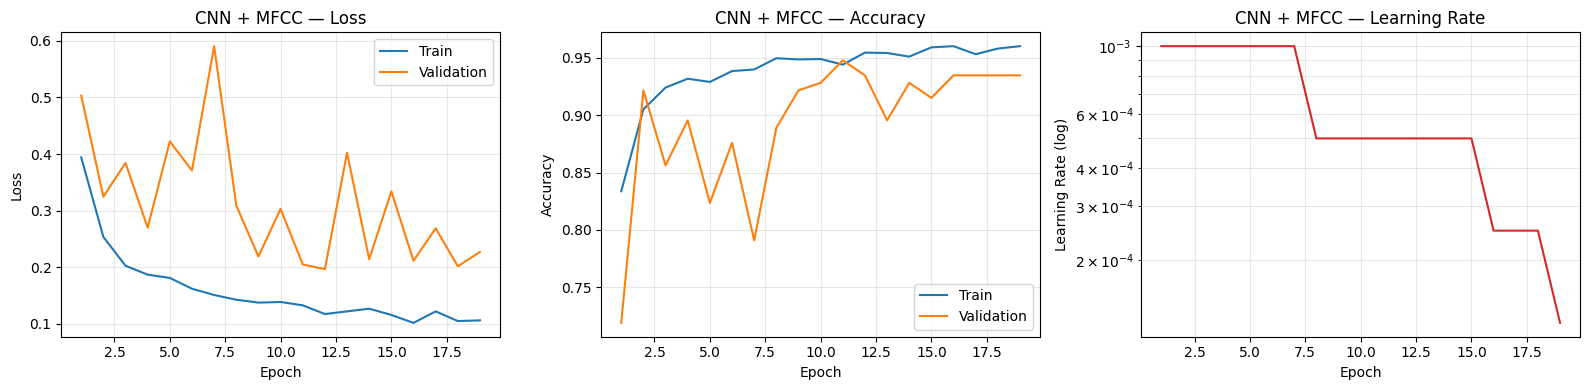

In [ ]:
print("\n" + "=" * 70)
print("4.3.5.3 Training: CNN + MFCC")
print("=" * 70)

mfcc_train_refs = load_feature_refs("mfcc_matrix", "train", orig_only=False)
mfcc_val_refs   = load_feature_refs("mfcc_matrix", "val",   orig_only=True)
mfcc_test_refs  = load_feature_refs("mfcc_matrix", "test",  orig_only=True)

sample_mfcc_path = Path(mfcc_train_refs.iloc[0]["npy_path"])
if not sample_mfcc_path.exists():
    raise FileNotFoundError(f"Contoh file MFCC .npy tidak ditemukan: {sample_mfcc_path}")
M_sample = np.load(sample_mfcc_path)
n_mfcc_coef, n_frames_mfcc = M_sample.shape
print(f"MFCC matrix shape: ({n_mfcc_coef}, {n_frames_mfcc})")

# Sanity check: konsistensi dimensi temporal antar varian
assert n_frames_mfcc == n_frames, (
    f"Jumlah frame MFCC ({n_frames_mfcc}) harus identik dengan Mel-spectrogram ({n_frames}) "
    f"untuk menjamin konsistensi dimensi temporal antar-varian eksperimen."
)

train_cnn_mfcc_ds = make_cnn_ds(mfcc_train_refs, (n_mfcc_coef, n_frames_mfcc), label2id, batch=BATCH, shuffle=True)
val_cnn_mfcc_ds   = make_cnn_ds(mfcc_val_refs,   (n_mfcc_coef, n_frames_mfcc), label2id, batch=BATCH, shuffle=False)
test_cnn_mfcc_ds  = make_cnn_ds(mfcc_test_refs,  (n_mfcc_coef, n_frames_mfcc), label2id, batch=BATCH, shuffle=False)

K.clear_session()
cnn_mfcc = build_cnn((n_mfcc_coef, n_frames_mfcc, 1), num_classes, cfg=CNN_CFG, name="CNN_MFCC")
cnn_mfcc.summary()

y_train_int_cnn_mfcc  = mfcc_train_refs["class"].astype(str).map(label2id).to_numpy(dtype=np.int32)
class_weight_cnn_mfcc = compute_class_weight_dict(y_train_int_cnn_mfcc)
print(f"CNN + MFCC — class weights: {class_weight_cnn_mfcc}")

ckpt_path_cnn_mfcc = str(ckpt_dir / "cnn_mfcc_best.keras")
csv_log_cnn_mfcc   = str(training_log_dir / "cnn_mfcc_epochs.csv")
cb_cnn_mfcc        = make_callbacks(ckpt_path_cnn_mfcc, csv_log_cnn_mfcc)

history_cnn_mfcc = cnn_mfcc.fit(
    train_cnn_mfcc_ds,
    validation_data=val_cnn_mfcc_ds,
    epochs=EXPERIMENT_CFG["max_epochs"],
    callbacks=cb_cnn_mfcc,
    class_weight=class_weight_cnn_mfcc,
    verbose=1,
)
summary_cnn_mfcc = save_training_artifacts(history_cnn_mfcc, "cnn_mfcc", training_log_dir)
dl_summaries.append(summary_cnn_mfcc)

# Prediksi label test set (untuk menghitung metrik klasifikasi)
y_true_cnn_mfcc, y_pred_cnn_mfcc = keras_predict_labels(cnn_mfcc, test_cnn_mfcc_ds)

# Pengukuran waktu inferensi per-sampel (single-sample latency)
print("\nMengukur waktu inferensi per-sampel...")
X_test_cnn_mfcc, _ = materialize_dataset(test_cnn_mfcc_ds)
inference_stats_cnn_mfcc = measure_inference_per_sample(
    model=cnn_mfcc,
    samples=X_test_cnn_mfcc,
    model_kind="keras",
    n_warmup=10,
)

cnn_mfcc_result = evaluate_classifier(
    name="CNN + MFCC",
    y_true=y_true_cnn_mfcc,
    y_pred=y_pred_cnn_mfcc,
    classes=classes,
    inference_stats=inference_stats_cnn_mfcc,
)
results.append(cnn_mfcc_result)
plot_training_history(history_cnn_mfcc, "CNN + MFCC")

### 4.3.5.4 LSTM + Mel-Spectrogram


4.3.5.4 Training: LSTM + Mel-spectrogram


Model: "LSTM_MelSpec"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 158, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 158, 128)  │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 158, 128)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 158)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 158, 64)   │     49,408 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,890 (241.76 KB)

 Trainable params: 61,890 (241.76 KB)

 Non-trainable params: 0 (0.00 B)

LSTM + MelSpec — class weights: {0: 1.2226027397260273, 1: 0.8459715639810427}
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.6250 - loss: 0.6622 - val_accuracy: 0.6928 - val_loss: 0.6070 - lr: 0.0010 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - accuracy: 0.7062 - loss: 0.6047 - val_accuracy: 0.7647 - val_loss: 0.5372 - lr: 0.0010 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.7742 - loss: 0.5283 - val_accuracy: 0.7647 - val_loss: 0.5296 - lr: 0.0010 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.8064 - loss: 0.4978 - val_accuracy: 0.6601 - val_loss: 0.6364 - lr: 0.0010 - learning_rate: 0.0010
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.7787 - loss: 0.5057 - val_accuracy: 0.8105 - val_loss: 0.4834 - lr: 0.0010 - learning_rate: 0.0010
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.8221 - loss: 0.482

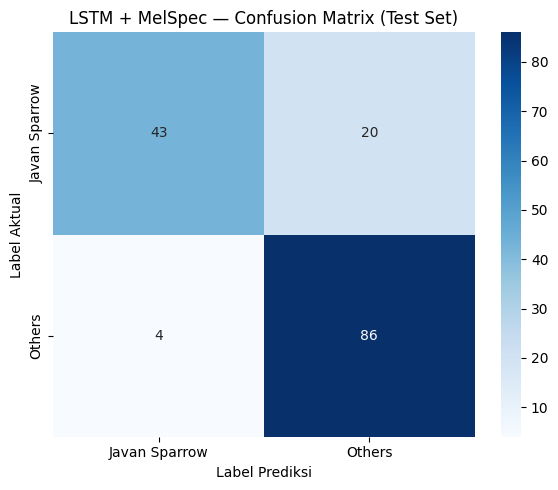

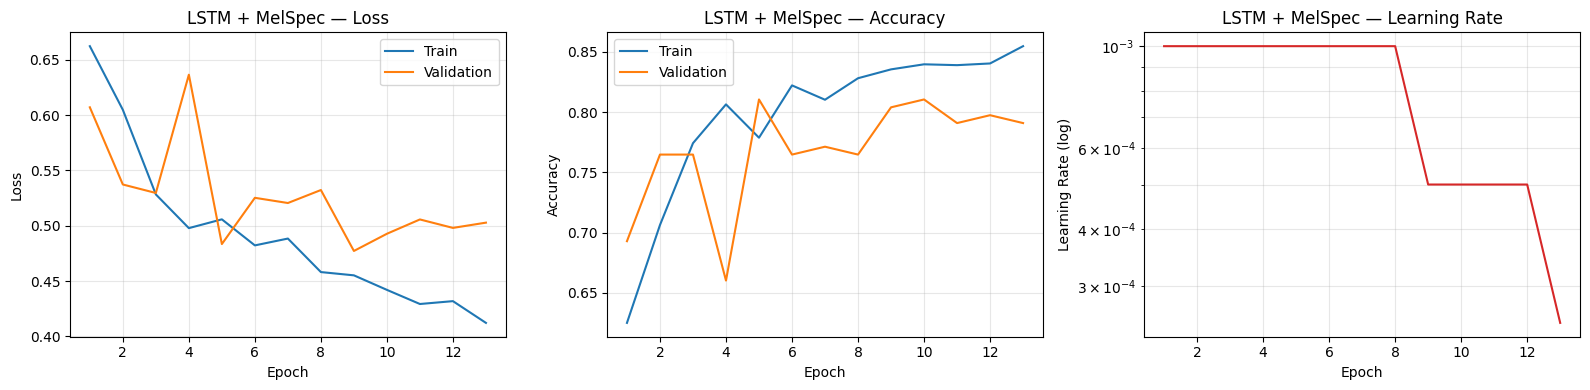

In [ ]:
print("\n" + "=" * 70)
print("4.3.5.4 Training: LSTM + Mel-spectrogram")
print("=" * 70)

train_lstm_melspec_ds = make_lstm_ds(spec_train_refs, (n_mels, n_frames), label2id, batch=BATCH, shuffle=True)
val_lstm_melspec_ds   = make_lstm_ds(spec_val_refs,   (n_mels, n_frames), label2id, batch=BATCH, shuffle=False)
test_lstm_melspec_ds  = make_lstm_ds(spec_test_refs,  (n_mels, n_frames), label2id, batch=BATCH, shuffle=False)

K.clear_session()
lstm_melspec = build_lstm((n_frames, n_mels), num_classes, cfg=LSTM_CFG, name="LSTM_MelSpec")
lstm_melspec.summary()

y_train_int_lstm_melspec  = spec_train_refs["class"].astype(str).map(label2id).to_numpy(dtype=np.int32)
class_weight_lstm_melspec = compute_class_weight_dict(y_train_int_lstm_melspec)
print(f"LSTM + MelSpec — class weights: {class_weight_lstm_melspec}")

ckpt_path_lstm_melspec = str(ckpt_dir / "lstm_melspec_best.keras")
csv_log_lstm_melspec   = str(training_log_dir / "lstm_melspec_epochs.csv")
cb_lstm_melspec        = make_callbacks(ckpt_path_lstm_melspec, csv_log_lstm_melspec)

history_lstm_melspec = lstm_melspec.fit(
    train_lstm_melspec_ds,
    validation_data=val_lstm_melspec_ds,
    epochs=EXPERIMENT_CFG["max_epochs"],
    callbacks=cb_lstm_melspec,
    class_weight=class_weight_lstm_melspec,
    verbose=1,
)
summary_lstm_melspec = save_training_artifacts(history_lstm_melspec, "lstm_melspec", training_log_dir)
dl_summaries.append(summary_lstm_melspec)

# Prediksi label test set (untuk menghitung metrik klasifikasi)
y_true_lstm_melspec, y_pred_lstm_melspec = keras_predict_labels(lstm_melspec, test_lstm_melspec_ds)

# Pengukuran waktu inferensi per-sampel (single-sample latency)
print("\nMengukur waktu inferensi per-sampel...")
X_test_lstm_melspec, _ = materialize_dataset(test_lstm_melspec_ds)
inference_stats_lstm_melspec = measure_inference_per_sample(
    model=lstm_melspec,
    samples=X_test_lstm_melspec,
    model_kind="keras",
    n_warmup=10,
)

lstm_melspec_result = evaluate_classifier(
    name="LSTM + MelSpec",
    y_true=y_true_lstm_melspec,
    y_pred=y_pred_lstm_melspec,
    classes=classes,
    inference_stats=inference_stats_lstm_melspec,
)
results.append(lstm_melspec_result)
plot_training_history(history_lstm_melspec, "LSTM + MelSpec")

### 4.3.5.5 LSTM + MFCC


4.3.5.5 Training: LSTM + MFCC


Model: "LSTM_MFCC"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 158, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 158, 40)   │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 158, 40)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 158)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 158, 64)   │     26,880 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,362 (153.76 KB)

 Trainable params: 39,362 (153.76 KB)

 Non-trainable params: 0 (0.00 B)

LSTM + MFCC — class weights: {0: 1.2226027397260273, 1: 0.8459715639810427}
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 0.7591 - loss: 0.4925 - val_accuracy: 0.8235 - val_loss: 0.4034 - lr: 0.0010 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.8869 - loss: 0.3082 - val_accuracy: 0.8562 - val_loss: 0.3109 - lr: 0.0010 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.9293 - loss: 0.2122 - val_accuracy: 0.8431 - val_loss: 0.3635 - lr: 0.0010 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - accuracy: 0.9174 - loss: 0.2120 - val_accuracy: 0.8824 - val_loss: 0.3074 - lr: 0.0010 - learning_rate: 0.0010
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.9184 - loss: 0.2013 - val_accuracy: 0.8627 - val_loss: 0.3430 - lr: 0.0010 - learning_rate: 0.0010
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.9345 - loss: 0.1862 -

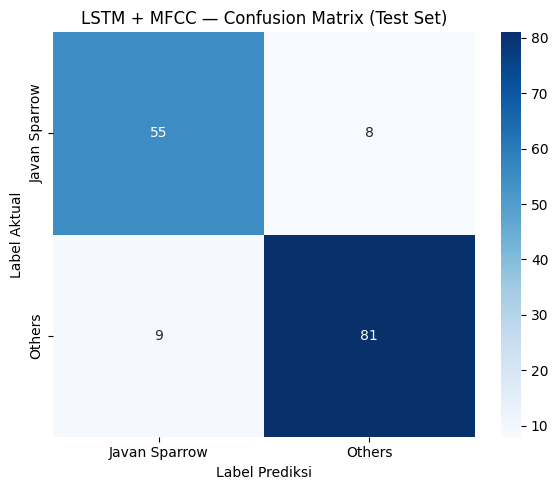

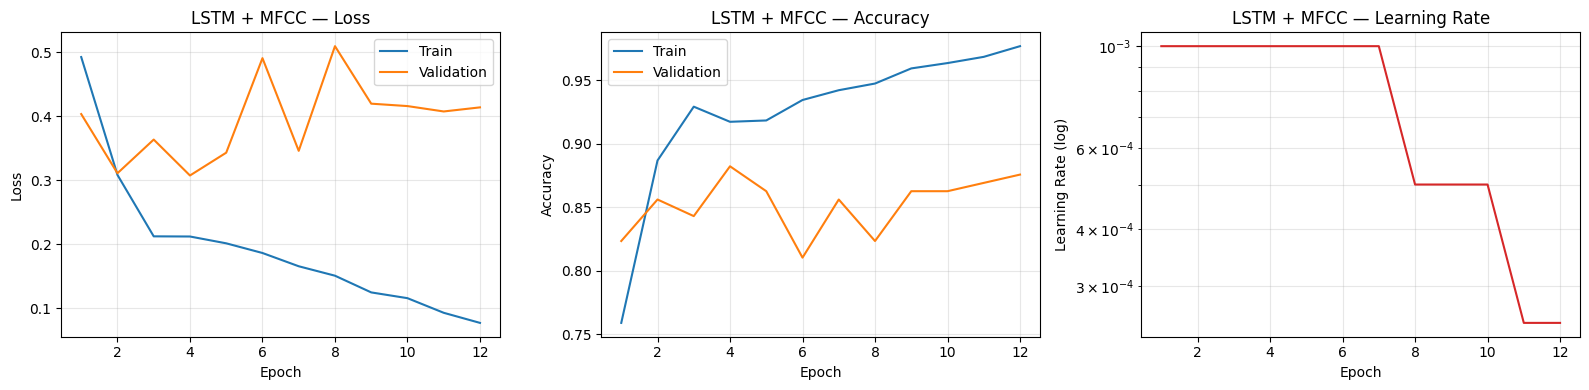

In [ ]:
print("\n" + "=" * 70)
print("4.3.5.5 Training: LSTM + MFCC")
print("=" * 70)

train_lstm_mfcc_ds = make_lstm_ds(mfcc_train_refs, (n_mfcc_coef, n_frames_mfcc), label2id, batch=BATCH, shuffle=True)
val_lstm_mfcc_ds   = make_lstm_ds(mfcc_val_refs,   (n_mfcc_coef, n_frames_mfcc), label2id, batch=BATCH, shuffle=False)
test_lstm_mfcc_ds  = make_lstm_ds(mfcc_test_refs,  (n_mfcc_coef, n_frames_mfcc), label2id, batch=BATCH, shuffle=False)

K.clear_session()
lstm_mfcc = build_lstm((n_frames_mfcc, n_mfcc_coef), num_classes, cfg=LSTM_CFG, name="LSTM_MFCC")
lstm_mfcc.summary()

y_train_int_lstm_mfcc  = mfcc_train_refs["class"].astype(str).map(label2id).to_numpy(dtype=np.int32)
class_weight_lstm_mfcc = compute_class_weight_dict(y_train_int_lstm_mfcc)
print(f"LSTM + MFCC — class weights: {class_weight_lstm_mfcc}")

ckpt_path_lstm_mfcc = str(ckpt_dir / "lstm_mfcc_best.keras")
csv_log_lstm_mfcc   = str(training_log_dir / "lstm_mfcc_epochs.csv")
cb_lstm_mfcc        = make_callbacks(ckpt_path_lstm_mfcc, csv_log_lstm_mfcc)

history_lstm_mfcc = lstm_mfcc.fit(
    train_lstm_mfcc_ds,
    validation_data=val_lstm_mfcc_ds,
    epochs=EXPERIMENT_CFG["max_epochs"],
    callbacks=cb_lstm_mfcc,
    class_weight=class_weight_lstm_mfcc,
    verbose=1,
)
summary_lstm_mfcc = save_training_artifacts(history_lstm_mfcc, "lstm_mfcc", training_log_dir)
dl_summaries.append(summary_lstm_mfcc)

# Prediksi label test set (untuk menghitung metrik klasifikasi)
y_true_lstm_mfcc, y_pred_lstm_mfcc = keras_predict_labels(lstm_mfcc, test_lstm_mfcc_ds)

# Pengukuran waktu inferensi per-sampel (single-sample latency)
print("\nMengukur waktu inferensi per-sampel...")
X_test_lstm_mfcc, _ = materialize_dataset(test_lstm_mfcc_ds)
inference_stats_lstm_mfcc = measure_inference_per_sample(
    model=lstm_mfcc,
    samples=X_test_lstm_mfcc,
    model_kind="keras",
    n_warmup=10,
)

lstm_mfcc_result = evaluate_classifier(
    name="LSTM + MFCC",
    y_true=y_true_lstm_mfcc,
    y_pred=y_pred_lstm_mfcc,
    classes=classes,
    inference_stats=inference_stats_lstm_mfcc,
)
results.append(lstm_mfcc_result)
plot_training_history(history_lstm_mfcc, "LSTM + MFCC")

# Model Evaluation

Konsolidasi seluruh hasil eksperimen ke dalam tabel komparatif (akurasi, *macro F1-score*, dan statistik *single-sample latency*) serta visualisasi *confusion matrix* per varian eksperimen. Tabel yang dihasilkan menjadi sumber utama pembahasan pada Bab V laporan.

In [ ]:
results_df        = pd.DataFrame(results)
results_df_sorted = results_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)

display_cols = [
    "name", "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "infer_ms_mean", "infer_ms_std", "infer_ms_median", "infer_ms_p95",
]

print("\n" + "=" * 80)
print("HASIL KOMPARATIF — Diurutkan berdasarkan F1-macro (descending)")
print("=" * 80)
print(results_df_sorted[display_cols].to_string(
    index=False,
    formatters={
        "accuracy":         "{:.4f}".format,
        "precision_macro":  "{:.4f}".format,
        "recall_macro":     "{:.4f}".format,
        "f1_macro":         "{:.4f}".format,
        "infer_ms_mean":    "{:.4f}".format,
        "infer_ms_std":     "{:.4f}".format,
        "infer_ms_median":  "{:.4f}".format,
        "infer_ms_p95":     "{:.4f}".format,
    },
))

# Ringkasan training DL
if dl_summaries:
    training_summary_df = pd.DataFrame(dl_summaries)
    training_summary_csv = training_log_dir / "dl_training_summary.csv"
    training_summary_df.to_csv(training_summary_csv, index=False)

    print("\n" + "=" * 80)
    print("RINGKASAN TRAINING DEEP LEARNING — Best Epoch per Model")
    print("=" * 80)
    print(training_summary_df.to_string(
        index=False,
        formatters={
            "best_val_accuracy":   "{:.4f}".format,
            "best_val_loss":       "{:.4f}".format,
            "best_train_accuracy": "{:.4f}".format,
            "best_train_loss":     "{:.4f}".format,
            "initial_lr":          "{:.2e}".format,
            "final_lr":            "{:.2e}".format,
        },
    ))
    print(f"\nRingkasan disimpan ke: {training_summary_csv}")

# Persist hasil komparatif untuk dilaporkan pada Bab 5
results_csv_path = model_dir / "comparative_results.csv"
results_df_sorted.to_csv(results_csv_path, index=False)
print(f"\nHasil komparatif disimpan ke: {results_csv_path}")


HASIL KOMPARATIF — Diurutkan berdasarkan F1-macro (descending)
          name accuracy precision_macro recall_macro f1_macro infer_ms_mean infer_ms_std infer_ms_median infer_ms_p95
    CNN + MFCC   0.9673          0.9632       0.9722   0.9666       83.6886      20.9703         73.2615     134.8525
     RF + MFCC   0.9542          0.9538       0.9516   0.9527       45.6860       5.6750         44.2871      55.6596
 CNN + MelSpec   0.9346          0.9305       0.9421   0.9336       86.8735      22.0150         77.0056     138.7648
   LSTM + MFCC   0.8889          0.8847       0.8865   0.8856       91.4846      19.7279         81.8266     134.5353
LSTM + MelSpec   0.8431          0.8631       0.8190   0.8297       91.5308      19.6038         82.0737     138.2980

RINGKASAN TRAINING DEEP LEARNING — Best Epoch per Model
  model_name  total_epochs  best_epoch      monitor best_val_accuracy best_val_loss best_train_accuracy best_train_loss initial_lr final_lr
 cnn_melspec            17     

In [ ]:
# Persistensi prediksi per-sampel untuk verifikasi pipeline aplikasi
import pandas as pd
import numpy as np

# Verifikasi prasyarat — variabel-variabel ini sudah ada setelah training selesai
required_vars = {
    "cnn_mfcc":          "Model CNN+MFCC",
    "rf_final":          "Model Random Forest final",
    "test_cnn_mfcc_ds":  "Test dataset untuk CNN+MFCC",
    "X_test":            "Vektor MFCC test set untuk RF",
    "y_test":            "Label test set",
    "mfcc_test_refs":    "Referensi berkas test set",
    "label2id":          "Pemetaan label",
}
for var_name, desc in required_vars.items():
    assert var_name in dir(), f"{desc} ({var_name}) belum tersedia. Periksa eksekusi cell sebelumnya."

assert len(mfcc_test_refs) == len(y_test), (
    f"Mismatch jumlah: mfcc_test_refs={len(mfcc_test_refs)}, y_test={len(y_test)}"
)

print(f"Memproses prediksi per-sampel untuk {len(y_test)} sampel test set...")

cnn_mfcc_probs = cnn_mfcc.predict(test_cnn_mfcc_ds, verbose=0)
cnn_mfcc_preds = np.argmax(cnn_mfcc_probs, axis=1)
cnn_mfcc_conf  = np.max(cnn_mfcc_probs, axis=1)

rf_probs = rf_final.predict_proba(X_test)
rf_preds = np.argmax(rf_probs, axis=1)
rf_conf  = np.max(rf_probs, axis=1)

id2label_map = {v: k for k, v in label2id.items()}

verification_df = pd.DataFrame({
    "file_id":          mfcc_test_refs["file_id"].values,
    "actual_label":     [id2label_map[i] for i in y_test],
    "cnn_mfcc_pred":    [id2label_map[i] for i in cnn_mfcc_preds],
    "cnn_mfcc_conf":    cnn_mfcc_conf,
    "cnn_mfcc_correct": (cnn_mfcc_preds == y_test),
    "rf_pred":          [id2label_map[i] for i in rf_preds],
    "rf_conf":          rf_conf,
    "rf_correct":       (rf_preds == y_test),
})

acc_cnn_verify = verification_df["cnn_mfcc_correct"].mean()
acc_rf_verify  = verification_df["rf_correct"].mean()
acc_cnn_report = results_df.loc[results_df["name"] == "CNN + MFCC", "accuracy"].iloc[0]
acc_rf_report  = results_df.loc[results_df["name"] == "RF + MFCC",  "accuracy"].iloc[0]

print(f"  CNN+MFCC sanity: verify={acc_cnn_verify:.4f}, report={acc_cnn_report:.4f}, "
      f"match={'✓' if abs(acc_cnn_verify - acc_cnn_report) < 1e-3 else '✗'}")
print(f"  RF+MFCC sanity:  verify={acc_rf_verify:.4f}, report={acc_rf_report:.4f}, "
      f"match={'✓' if abs(acc_rf_verify - acc_rf_report) < 1e-3 else '✗'}")

# Persist
verification_path = training_log_dir / "verification_data.csv"
verification_df.to_csv(verification_path, index=False)
print(f"\n✓ Tersimpan: {verification_path}")
print(f"  Total: {len(verification_df)} sampel dengan prediksi dari 2 varian")
print()
print("Pratinjau:")
print(verification_df.head())

Memproses prediksi per-sampel untuk 153 sampel test set...
  CNN+MFCC sanity: verify=0.9673, report=0.9673, match=✓
  RF+MFCC sanity:  verify=0.9542, report=0.9542, match=✓

✓ Tersimpan: /content/drive/MyDrive/UAJY/Gelatik Jawa/Features/training_logs/verification_data.csv
  Total: 153 sampel dengan prediksi dari 2 varian

Pratinjau:
               file_id   actual_label  cnn_mfcc_pred  cnn_mfcc_conf  \
0  Macaulay__190288771  Javan Sparrow  Javan Sparrow       0.999624   
1  Macaulay__190396021  Javan Sparrow  Javan Sparrow       0.991010   
2  Macaulay__279106261  Javan Sparrow  Javan Sparrow       0.991738   
3  Macaulay__390987691  Javan Sparrow  Javan Sparrow       0.989573   
4  Macaulay__505036131  Javan Sparrow  Javan Sparrow       0.997139   

   cnn_mfcc_correct        rf_pred   rf_conf  rf_correct  
0              True  Javan Sparrow  0.500959        True  
1              True  Javan Sparrow  0.575298        True  
2              True  Javan Sparrow  0.547469        True  
3 

# Model Implementation

Persistensi seluruh artefak model dan metadata *pipeline* untuk konsumsi oleh aplikasi inferensi Streamlit. Random Forest dipersist ke format Joblib, empat model *deep learning* ke format Keras native, dan satu *file* `model_metadata.json` berisi seluruh konfigurasi audio, fitur, dan dimensi *input* per varian.

In [ ]:
# ── Persist Random Forest (joblib) ───────────────────────────────────────
joblib.dump(rf_final, model_dir / "rf_mfcc.joblib")
print(f"✓ RF + MFCC      -> {model_dir / 'rf_mfcc.joblib'}")

✓ RF + MFCC      -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Models/rf_mfcc.joblib


In [ ]:
# ── Persist model deep learning (format Keras native) ────────────────────
dl_models = {
    "cnn_melspec":  cnn_melspec,
    "cnn_mfcc":     cnn_mfcc,
    "lstm_melspec": lstm_melspec,
    "lstm_mfcc":    lstm_mfcc,
}

for model_key, model_obj in dl_models.items():
    save_path = model_dir / f"{model_key}.keras"
    model_obj.save(save_path)
    print(f"✓ {model_key:<14} -> {save_path}")

✓ cnn_melspec    -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Models/cnn_melspec.keras
✓ cnn_mfcc       -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Models/cnn_mfcc.keras
✓ lstm_melspec   -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Models/lstm_melspec.keras
✓ lstm_mfcc      -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Models/lstm_mfcc.keras


In [ ]:
# ── Persist metadata deployment ──────────────────────────────────────────
classes, label2id, id2label, num_classes = load_label_meta()

metadata = {
    "label_meta_ref": "Meta/label_meta.json",
    "audio_cfg":      asdict(AUDIO_CFG),
    "feature_cfg":    asdict(FEATURE_CFG),
    "split_cfg":      SPLIT_CFG,
    "model_files": {
        "rf_mfcc":      "rf_mfcc.joblib",
        "cnn_melspec":  "cnn_melspec.keras",
        "cnn_mfcc":     "cnn_mfcc.keras",
        "lstm_melspec": "lstm_melspec.keras",
        "lstm_mfcc":    "lstm_mfcc.keras",
    },
    "input_shapes": {
        "cnn_melspec":  {"n_mels":   n_mels,         "n_frames":     n_frames},
        "cnn_mfcc":     {"n_mfcc":   n_mfcc_coef,    "n_frames":     n_frames_mfcc},
        "lstm_melspec": {"n_frames": n_frames,       "n_mels":       n_mels},
        "lstm_mfcc":    {"n_frames": n_frames_mfcc,  "n_mfcc_coef":  n_mfcc_coef},
    },
    "model_cfgs": {
        "rf": {**RF_FIXED, **best_params},
        "cnn":  CNN_CFG,
        "lstm": LSTM_CFG,
    },
    "training_cfg": EXPERIMENT_CFG,
}

metadata_path = model_dir / "model_metadata.json"
with open(metadata_path, "w") as f:
    # joblib RandomForestClassifier punya field non-serializable (n_jobs func ref tidak),
    # tapi RF_CFG dict kita bersih—aman untuk json.dump.
    json.dump(metadata, f, indent=2, default=str)

print(f"\nMetadata disimpan ke: {metadata_path}")


Metadata disimpan ke: /content/drive/MyDrive/UAJY/Gelatik Jawa/Models/model_metadata.json


# Testing

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Validasi Eksternal — Pengujian pada Dataset Independen ("Test Dataset")
# ═══════════════════════════════════════════════════════════════════════════
# Tahap ini menguji kelima kombinasi model-fitur terlatih pada himpunan data
# yang sepenuhnya baru dan tidak pernah terlibat dalam proses pelatihan,
# validasi, maupun pengujian internal. Tujuannya adalah mengukur kemampuan
# generalisasi model terhadap kondisi akuisisi di luar distribusi data latih.

# Rerun load_label_meta(), load_fixed_length()

# ── Direktori sumber dan keluaran ─────────────────────────────────────────
demo_path = Path('/content/drive/MyDrive/Demo Dataset')
EXT_TEST_PATH = demo_path
# EXT_TEST_PATH = parent_path / "Test Dataset"          # berisi: Javan Sparrow/, Others/
EXT_OUT_DIR   = training_log_dir / "external_validation"
EXT_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not EXT_TEST_PATH.is_dir():
    raise FileNotFoundError(f"Direktori uji eksternal tidak ditemukan: {EXT_TEST_PATH}")

# ── Direktori staging preprocessing ───────────────────────────────────────
# Struktur direktori dibuat identik dengan tahap Data Preparation (Sub-bab
# 3.2.1) agar keluaran tiap tahap dapat diaudit secara terpisah.
ext_prep_path = prep_path / "Test Dataset"
ext_stage_paths = {
    "wav":      ext_prep_path / "01_wav16k",
    "denoise":  ext_prep_path / "02_denoised",
    "normloud": ext_prep_path / "03_normloud",
    "fixedlen": ext_prep_path / "04_fixedlen",
}
for p in ext_stage_paths.values():
    p.mkdir(parents=True, exist_ok=True)

# ── Muat metadata deployment dan label mapping ────────────────────────────
metadata_path = model_dir / "model_metadata.json"
if not metadata_path.exists():
    raise FileNotFoundError(
        f"Metadata model tidak ditemukan: {metadata_path}. "
        f"Jalankan tahap Model Implementation terlebih dahulu."
    )
with open(metadata_path) as f:
    META = json.load(f)

AUDIO_CFG_EXT   = AudioCfg(**META["audio_cfg"])
FEATURE_CFG_EXT = FeatureCfg(**META["feature_cfg"])
classes, label2id, id2label, num_classes = load_label_meta()

# ── Muat kelima model terlatih dari Google Drive ──────────────────────────
# Verifikasi keberadaan seluruh artefak dilakukan sebelum pemuatan agar
# kegagalan terdeteksi lebih awal, bukan setelah sebagian model terlanjur
# dimuat ke memori.
missing = [
    fn for fn in META["model_files"].values()
    if not (model_dir / fn).exists()
]
if missing:
    raise FileNotFoundError(f"Berkas model tidak ditemukan di {model_dir}: {missing}")

rf_loaded = joblib.load(model_dir / META["model_files"]["rf_mfcc"])
keras_loaded = {
    key: tf.keras.models.load_model(model_dir / META["model_files"][key])
    for key in ("cnn_melspec", "cnn_mfcc", "lstm_melspec", "lstm_mfcc")
}

print(f"Kelas          : {classes}")
print(f"Konfigurasi    : sr={AUDIO_CFG_EXT.sr}, durasi={AUDIO_CFG_EXT.duration_s}s, "
      f"n_mfcc={FEATURE_CFG_EXT.n_mfcc}, n_mels={FEATURE_CFG_EXT.n_mels}")
print(f"Model dimuat   : rf_mfcc + {list(keras_loaded.keys())}")
print(f"Direktori uji  : {EXT_TEST_PATH}")
print(f"Direktori hasil: {EXT_OUT_DIR}")

Kelas          : ['Javan Sparrow', 'Others']
Konfigurasi    : sr=16000, durasi=5.0s, n_mfcc=40, n_mels=128
Model dimuat   : rf_mfcc + ['cnn_melspec', 'cnn_mfcc', 'lstm_melspec', 'lstm_mfcc']
Direktori uji  : /content/drive/MyDrive/Demo Dataset
Direktori hasil: /content/drive/MyDrive/UAJY/Gelatik Jawa/Features/training_logs/external_validation


In [14]:
# ── Rantai preprocessing data uji eksternal ───────────────────────────────
# Keempat tahap dijalankan dengan memanggil ulang fungsi yang identik dengan
# tahap Data Preparation (Sub-bab 3.2.1): convert_to_wav, reduce_noise,
# normalize_volume, dan normalize_duration. Penggunaan kembali fungsi yang
# sama — bukan replikasi logikanya — menjamin data uji eksternal berada pada
# domain sinyal yang persis sama dengan data latih, sehingga setiap penurunan
# performa yang teramati dapat diatribusikan pada kemampuan generalisasi
# model, bukan pada perbedaan perlakuan praproses.

AUDIO_EXTS = ('.wav', '.flac', '.mp3', '.ogg', '.m4a')

for p in ext_stage_paths.values():
    reset_dir(p, force=True)

# ── Inventarisasi berkas sumber ───────────────────────────────────────────
src_files = [
    (Path(root) / fn, cls)
    for cls in sorted(os.listdir(EXT_TEST_PATH))
    if (EXT_TEST_PATH / cls).is_dir()
    for root, _, files in os.walk(EXT_TEST_PATH / cls)
    for fn in sorted(files) if fn.lower().endswith(AUDIO_EXTS)
]

unknown = {cls for _, cls in src_files} - set(label2id)
if unknown:
    raise ValueError(f"Folder kelas tidak dikenali: {unknown}. Kelas valid: {classes}")

print(f"Total berkas uji eksternal: {len(src_files)}")
print(pd.Series([c for _, c in src_files]).value_counts().to_string())

# ── Stage 1: Konversi ke WAV 16 kHz mono ──────────────────────────────────
stage1_files = []
for src, cls in tqdm(src_files, desc="Stage 1 — Konversi WAV", unit="file"):
    dst_dir = ext_stage_paths["wav"] / cls
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / f"{sanitize_filename(src.stem)}.wav"
    if convert_to_wav(str(src), str(dst), target_sr=AUDIO_CFG_EXT.sr):
        stage1_files.append((dst, cls))
print(f"Stage 1 selesai: {len(stage1_files)}/{len(src_files)} file")

# ── Stage 2–4: Noise reduction → Normalisasi volume → Normalisasi durasi ──
STAGES = [
    ("denoise",  "wav",      "Stage 2 — Noise Reduction",
     lambda s, d: reduce_noise(s, d)),
    ("normloud", "denoise",  "Stage 3 — Volume Normalization",
     lambda s, d: normalize_volume(s, d, target_dBFS=-20.0)),
    ("fixedlen", "normloud", "Stage 4 — Duration Normalization",
     lambda s, d: normalize_duration(s, d, target_sr=AUDIO_CFG_EXT.sr,
                                     target_duration=AUDIO_CFG_EXT.duration_s)),
]

stage_files = stage1_files
for dst_key, src_key, desc, fn in STAGES:
    next_files = []
    for src, cls in tqdm(stage_files, desc=desc, unit="file"):
        dst_dir = ext_stage_paths[dst_key] / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / src.name
        if fn(str(src), str(dst)):
            next_files.append((dst, cls))
    stage_files = next_files
    print(f"{desc} selesai: {len(stage_files)} file -> {ext_stage_paths[dst_key]}")

ext_files  = [str(fp) for fp, _ in stage_files]
ext_labels = [cls for _, cls in stage_files]

# ── Ekstraksi fitur (augment=False — data uji dipertahankan apa adanya) ────
# Fungsi _length dan extract_features dipanggil ulang dari tahap
# Feature Engineering (Sub-bab 3.2.2), sehingga parameter n_mfcc, n_mels,
# n_fft, hop_length, dan fmax dijamin identik dengan konfigurasi pelatihan.
vec_list, mat_list, spec_list = [], [], []
for fp in tqdm(ext_files, desc="Ekstraksi fitur", unit="file"):
    y = load_fixed_length(fp, AUDIO_CFG_EXT)
    mfcc_vec, mfcc_mat, S_db = extract_features(y, AUDIO_CFG_EXT, FEATURE_CFG_EXT)
    vec_list.append(mfcc_vec); mat_list.append(mfcc_mat); spec_list.append(S_db)

X_vec  = np.stack(vec_list)     # (N, 40)       → RF + MFCC
X_mfcc = np.stack(mat_list)     # (N, 40, 157)  → CNN/LSTM + MFCC
X_spec = np.stack(spec_list)    # (N, 128, 157) → CNN/LSTM + Mel-spectrogram
y_ext  = np.array([label2id[l] for l in ext_labels], dtype=np.int32)

print(f"\nX_vec: {X_vec.shape} | X_mfcc: {X_mfcc.shape} | X_spec: {X_spec.shape}")

Total berkas uji eksternal: 40
Javan Sparrow    20
Others           20


Stage 1 — Konversi WAV:   0%|          | 0/40 [00:00<?, ?file/s]

Stage 1 selesai: 40/40 file


Stage 2 — Noise Reduction:   0%|          | 0/40 [00:00<?, ?file/s]

Stage 2 — Noise Reduction selesai: 40 file -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Preprocessed Audio/Test Dataset/02_denoised


...

Stage 3 — Volume Normalization selesai: 40 file -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Preprocessed Audio/Test Dataset/03_normloud


Stage 4 — Duration Normalization:   0%|          | 0/40 [00:00<?, ?file/s]

Stage 4 — Duration Normalization selesai: 40 file -> /content/drive/MyDrive/UAJY/Gelatik Jawa/Preprocessed Audio/Test Dataset/04_fixedlen


Ekstraksi fitur:   0%|          | 0/40 [00:00<?, ?file/s]


X_vec: (40, 40) | X_mfcc: (40, 40, 158) | X_spec: (40, 128, 158)


In [15]:
# ── Susun tensor masukan sesuai kontrak dimensi tiap arsitektur ───────────
# CNN  : (H, W, 1)  — kanal tunggal ditambahkan pada sumbu terakhir
# LSTM : (T, F)     — matriks (F, T) ditranspos agar sumbu temporal mendahului
inputs = {
    "cnn_mfcc":     X_mfcc[..., np.newaxis],
    "cnn_melspec":  X_spec[..., np.newaxis],
    "lstm_mfcc":    np.transpose(X_mfcc, (0, 2, 1)),
    "lstm_melspec": np.transpose(X_spec, (0, 2, 1)),
}

DISPLAY_NAME = {
    "rf_mfcc":      "RF + MFCC",
    "cnn_mfcc":     "CNN + MFCC",
    "cnn_melspec":  "CNN + Mel-spectrogram",
    "lstm_mfcc":    "LSTM + MFCC",
    "lstm_melspec": "LSTM + Mel-spectrogram",
}

probs = {"rf_mfcc": rf_loaded.predict_proba(X_vec)}
for key, model in keras_loaded.items():
    probs[key] = model.predict(inputs[key], verbose=0)

# ── Tabel prediksi per-berkas ─────────────────────────────────────────────
ext_df = pd.DataFrame({
    "file":         [Path(fp).name for fp in ext_files],
    "actual_label": ext_labels,
})
for key in DISPLAY_NAME:
    pred = probs[key].argmax(axis=1)
    ext_df[f"{key}_pred"]    = [id2label[i] for i in pred]
    ext_df[f"{key}_conf"]    = probs[key].max(axis=1)
    ext_df[f"{key}_correct"] = (pred == y_ext)

# Konsensus mayoritas lima model (analisis pendukung, bukan model utama)
pred_cols = [f"{k}_pred" for k in DISPLAY_NAME]
ext_df["consensus"]       = ext_df[pred_cols].mode(axis=1).iloc[:, 0]
ext_df["n_agree"]         = ext_df[pred_cols].eq(ext_df["consensus"], axis=0).sum(axis=1)
ext_df["consensus_correct"] = ext_df["consensus"] == ext_df["actual_label"]

pd.set_option("display.max_rows", 200, "display.width", 200)
print("PREDIKSI PER-BERKAS — DATASET UJI EKSTERNAL")
display(ext_df[["file", "actual_label"] +
               [c for k in DISPLAY_NAME for c in (f"{k}_pred", f"{k}_conf")] +
               ["consensus", "n_agree"]]
        .style.format({f"{k}_conf": "{:.3f}" for k in DISPLAY_NAME}))

PREDIKSI PER-BERKAS — DATASET UJI EKSTERNAL


,file,actual_label,rf_mfcc_pred,rf_mfcc_conf,cnn_mfcc_pred,cnn_mfcc_conf,cnn_melspec_pred,cnn_melspec_conf,lstm_mfcc_pred,lstm_mfcc_conf,lstm_melspec_pred,lstm_melspec_conf,consensus,n_agree
0,187578981.wav,Javan Sparrow,Javan Sparrow,0.958,Javan Sparrow,0.926,Javan Sparrow,0.945,Javan Sparrow,0.994,Javan Sparrow,0.848,Javan Sparrow,5
1,350579721.wav,Javan Sparrow,Javan Sparrow,0.944,Javan Sparrow,0.983,Javan Sparrow,0.897,Javan Sparrow,0.997,Javan Sparrow,0.742,Javan Sparrow,5
2,365637011.wav,Javan Sparrow,Javan Sparrow,0.946,Javan Sparrow,0.993,Javan Sparrow,0.831,Javan Sparrow,0.996,Javan Sparrow,0.937,Javan Sparrow,5
3,373488201.wav,Javan Sparrow,Javan Sparrow,0.904,Javan Sparrow,0.989,Javan Sparrow,0.897,Javan Sparrow,0.996,Javan Sparrow,0.938,Javan Sparrow,5
4,390987691.wav,Javan Sparrow,Javan Sparrow,0.862,Javan Sparrow,0.988,Javan Sparrow,0.893,Javan Sparrow,0.997,Javan Sparrow,0.937,Javan Sparrow,5
5,492563481.wav,Javan Sparrow,Javan Sparrow,0.938,Javan Sparrow,0.995,Javan Sparrow,0.979,Javan Sparrow,0.997,Javan Sparrow,0.941,Javan Sparrow,5
6,516607381.wav,Javan Sparrow,Javan Sparrow,0.806,Javan Sparrow,0.890,Javan Sparrow,0.931,Javan Sparrow,0.997,Javan Sparrow,0.938,Javan Sparrow,5
7,531189271.wav,Javan Sparrow,Javan Sparrow,0.906,Javan Sparrow,0.872,Javan Sparrow,0.654,Javan Sparrow,0.993,Javan Sparrow,0.936,Javan Sparrow,5
8,614241002.wav,Javan Sparrow,Javan Sparrow,0.990,Javan Sparrow,0.996,Javan Sparrow,0.998,Javan Sparrow,0.991,Javan Sparrow,0.695,Javan Sparrow,5
9,614806510.wav,Javan Sparrow,Javan Sparrow,1.000,Javan Sparrow,0.968,Javan Sparrow,0.995,Javan Sparrow,0.996,Javan Sparrow,0.938,Javan Sparrow,5



HASIL VALIDASI EKSTERNAL — Diurutkan berdasarkan F1-macro (descending)
                  name  accuracy  precision_macro  recall_macro  f1_macro  mean_conf  mean_conf_correct  mean_conf_incorrect
             RF + MFCC    1.0000           1.0000        1.0000    1.0000     0.9303             0.9303                  NaN
           LSTM + MFCC    0.9750           0.9762        0.9750    0.9750     0.9716             0.9710               0.9944
            CNN + MFCC    0.9500           0.9545        0.9500    0.9499     0.9575             0.9569               0.9685
LSTM + Mel-spectrogram    0.9500           0.9545        0.9500    0.9499     0.8435             0.8392               0.9254
 CNN + Mel-spectrogram    0.8750           0.8836        0.8750    0.8743     0.8903             0.9119               0.7390

Akurasi konsensus mayoritas: 0.9750


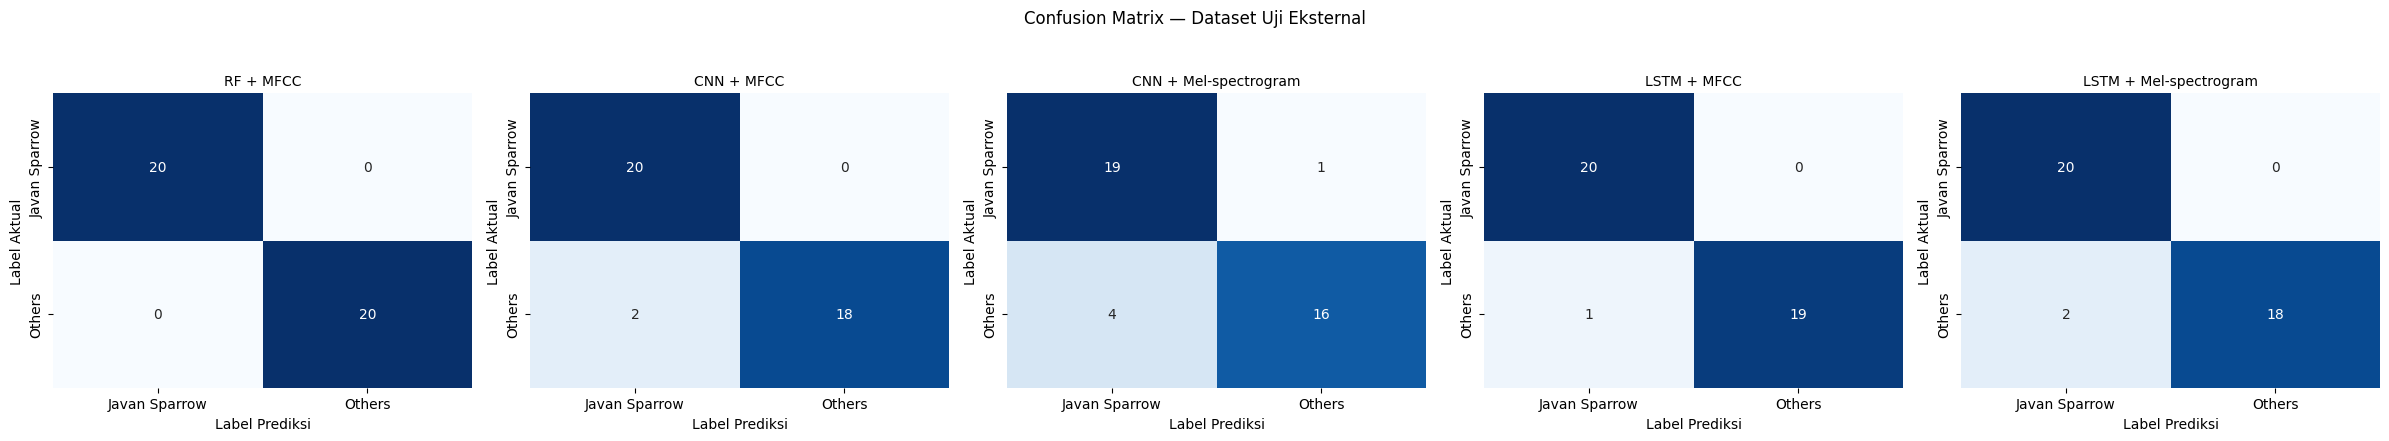


✓ Tersimpan: /content/drive/MyDrive/UAJY/Gelatik Jawa/Features/training_logs/external_validation/external_predictions.csv
✓ Tersimpan: /content/drive/MyDrive/UAJY/Gelatik Jawa/Features/training_logs/external_validation/external_metrics.csv


In [16]:
# ── Metrik agregat per kombinasi model-fitur ──────────────────────────────
ext_results = []
for key, name in DISPLAY_NAME.items():
    pred = probs[key].argmax(axis=1)
    ext_results.append({
        "name":            name,
        "accuracy":        accuracy_score(y_ext, pred),
        "precision_macro": precision_score(y_ext, pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_ext, pred, average="macro", zero_division=0),
        "f1_macro":        f1_score(y_ext, pred, average="macro", zero_division=0),
        "mean_conf":       float(probs[key].max(axis=1).mean()),
        "mean_conf_correct":   float(probs[key].max(axis=1)[pred == y_ext].mean()) if (pred == y_ext).any() else np.nan,
        "mean_conf_incorrect": float(probs[key].max(axis=1)[pred != y_ext].mean()) if (pred != y_ext).any() else np.nan,
    })

ext_results_df = pd.DataFrame(ext_results).sort_values("f1_macro", ascending=False)
print("\n" + "=" * 90)
print("HASIL VALIDASI EKSTERNAL — Diurutkan berdasarkan F1-macro (descending)")
print("=" * 90)
print(ext_results_df.to_string(index=False, float_format="{:.4f}".format))
print(f"\nAkurasi konsensus mayoritas: {ext_df['consensus_correct'].mean():.4f}")

# ── Confusion matrix per kombinasi ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4.2))
for ax, (key, name) in zip(axes, DISPLAY_NAME.items()):
    cm = confusion_matrix(y_ext, probs[key].argmax(axis=1), labels=range(num_classes))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Label Prediksi"); ax.set_ylabel("Label Aktual")
plt.suptitle("Confusion Matrix — Dataset Uji Eksternal", y=1.04)
plt.tight_layout(); plt.savefig(EXT_OUT_DIR / "external_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Persistensi hasil ─────────────────────────────────────────────────────
ext_df.to_csv(EXT_OUT_DIR / "external_predictions.csv", index=False)
ext_results_df.to_csv(EXT_OUT_DIR / "external_metrics.csv", index=False)
print(f"\n✓ Tersimpan: {EXT_OUT_DIR / 'external_predictions.csv'}")
print(f"✓ Tersimpan: {EXT_OUT_DIR / 'external_metrics.csv'}")